# **GTSRB - German Traffic Sign Recognition Benchmark**

## **1️⃣ - Introduction**


Le German Traffic Sign Recognition Benchmark (GTSRB) est un dataset de référence utilisé dans la classification automatique des panneaux de signalisation.

Avec l’essor des voitures autonomes et des systèmes d’aide à la conduite, il devient de plus en plus important de pouvoir identifier correctement les panneaux de signalisation. Ces panneaux jouent un rôle clé dans **la régulation du trafic** et **la sécurité des usagers**. Si un véhicule ou un système d’assistance ne les interprète pas correctement, cela peut entraîner des erreurs de conduite, comme un dépassement de vitesse involontaire ou un non-respect d’un stop. C’est pourquoi développer un modèle capable de reconnaître et classer automatiquement ces panneaux est essentiel pour assurer une **conduite plus sûre** et mieux **adaptée aux réglementations en vigueur**.

Le dataset GTSRB contient :

- Plus de 50 000 images de panneaux routiers prises dans différentes conditions.
- 43 classes différentes, représentant divers types de panneaux (limitation de vitesse, interdictions, dangers, etc.).
- Des images avec des variations d'éclairage, d’angles et de qualité, rendant la tâche plus proche des conditions réelles sur la route.

**1. Panneaux de limitation de vitesse**

- Ces panneaux indiquent la vitesse maximale autorisée sur une portion de route.
- Exemples : 30 km/h, 50 km/h, 80 km/h, 120 km/h…

**2. Panneaux d’interdiction**
- Ils signalent des actions interdites aux conducteurs.
- Exemples : Sens interdit, interdiction de dépasser, interdiction de tourner…

**3. Panneaux de danger**
- Ils avertissent d’un danger potentiel sur la route.
- Exemples : Route glissante, travaux, passage piéton, virage dangereux…

**4. Panneaux d’obligation**
- Ils imposent un comportement aux conducteurs.
- Exemples : Obligation de tourner à gauche, passage obligatoire, port de chaînes à neige…

**5. Panneaux de priorité**
- Ils régulent les priorités et les intersections.
- Exemples : Stop, cédez-le-passage, priorité à droite, fin de priorité…

### **Importations**

In [16]:
# Installer les bibliothèques nécessaires (uniquement si elles ne sont pas déjà installées)
#!pip install --quiet opencv-python-headless matplotlib  seaborn scikit-learn scikeras
#!pip install --quiet  tensorflow==2.15

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.8 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.9.0 which is incompatible.
tensorflow-decision-forests 1.10.0 requires tensorflow==2.17.0, but you have tensorflow 2.15.0 which is incompatible.
tensorflow-text 2.17.0 requires tensorflow<2.18,>=2.17.0, but you have tensorflow 2.15.0 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.15.0 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikeras 0.13.0 requires keras>=3.2.0, but you have keras 2.15.0 which is incompatible.
tensorflow-decision-forests 1.10.0 requires ten

In [17]:
import os
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Traitement des images
import cv2
from PIL import Image

# Préparation des données et division en ensembles
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Construction du modèle CNN
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.regularizers import l2
from scikeras.wrappers import KerasClassifier

# Évaluation du modèle
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# **2️⃣ - Préparation des données**

## **◾ Charger et explorer le dataset GTSRB**

In [18]:
import os

# Téléchargement manuel avec kaggle CLI
dataset_name = "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
dataset_path = "./gtsrb_dataset"

# Vérifier si le dataset est déjà téléchargé
if not os.path.exists(dataset_path):
    print("Téléchargement du dataset GTSRB...")
    os.system(f"kaggle datasets download -d {dataset_name} --unzip -p {dataset_path}")
    print("Dataset téléchargé et extrait avec succès.")
else:
    print("Le dataset est déjà présent, aucune action nécessaire.")

# Vérification du contenu du dossier
train_path = os.path.join(dataset_path, "train")
if os.path.exists(train_path):
    print("Contenu du dossier train :", os.listdir(train_path))
else:
    print("Le dossier 'train' n'existe pas, vérifie le chemin.")


Le dataset est déjà présent, aucune action nécessaire.
Contenu du dossier train : ['41', '26', '40', '21', '14', '9', '22', '31', '1', '18', '0', '42', '39', '28', '37', '11', '36', '8', '38', '32', '16', '33', '7', '13', '3', '6', '23', '24', '30', '15', '20', '35', '5', '10', '12', '34', '19', '27', '2', '25', '4', '17', '29']


### **Structure du dataset**

In [19]:
# Dossier principal
print("Contenu du dossier train :")
print(os.listdir(dataset_path))


Contenu du dossier train :
['Train', 'train', 'Meta', 'meta', 'Meta.csv', 'test', 'Test', 'Train.csv', 'Test.csv']


### **◾ Prétraitement des images et division du dataset**

Dans cette section, nous avons chargé et prétraité les images du dataset GTSRB.

Nous avons commencé par récupérer les chemins des images et leurs labels, puis nous avons appliqué des transformations essentielles :
- conversion en RGB
- redimensionnement à une taille uniforme (32x32)
- normalisation des pixels

Enfin, les labels ont été encodés en one-hot afin de les rendre exploitables par notre modèle de deep learning.

(PS : Parler de l'ajout du poids des classes)

In [20]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

# Définition de la taille des images
IMG_SIZE = (32, 32)

# Vérification du dataset
dataset_path = "./gtsrb_dataset/train"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Le dossier '{dataset_path}' n'existe pas. Vérifie le téléchargement du dataset.")

image_paths = []
labels = []

# Récupération des chemins des images et des labels
for class_label, class_name in enumerate(sorted(os.listdir(dataset_path))):
    class_dir = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):  # Vérification du format
                image_paths.append(img_path)
                labels.append(class_label)

# Chargement des images et prétraitement
X, y = [], []
for img_path, label in zip(image_paths, labels):
    try:
        img = Image.open(img_path).convert('RGB')  # Conversion en RGB
        img = img.resize(IMG_SIZE)  # Redimensionnement
        X.append(np.array(img))  # Conversion en tableau NumPy
        y.append(label)
    except Exception as e:
        print(f"Erreur lors du chargement de l'image {img_path}: {e}")

# Conversion en tableaux NumPy et normalisation
X = np.array(X, dtype=np.float32) / 255.0  # Normalisation des pixels
y = np.array(y, dtype=np.int32)
y = to_categorical(y, num_classes=len(set(y)))  # Encodage one-hot des labels

print("Shape du dataset:", X.shape, y.shape)


Shape du dataset: (39209, 32, 32, 3) (39209, 43)


### **◾ Augmentation des données**

Nous avons appliqué une augmentation des données sur l'ensemble d'entraînement pour améliorer la robustesse du modèle. Des transformations comme des rotations, translations et zooms ont été utilisées pour simuler des conditions variées.

Ensuite, nous avons séparé les données en entraînement et validation (80%-20%) et appliqué ces transformations uniquement sur l'entraînement

In [21]:
from sklearn.utils.class_weight import compute_class_weight

# Définition de l'augmentation des données
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Séparation en ensembles d'entraînement

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Exemple : y_train contient les étiquettes des classes

y_train_labels = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weight_dict = dict(enumerate(class_weights))

print("Poids des classes :", class_weight_dict)

it_train = datagen.flow(X_train, y_train, batch_size=64) # Application de l'augmentation uniquement sur l'entraînement


# Affichage des dimensions des ensembles
print("Ensemble d'entraînement:", X_train.shape, y_train.shape)



Poids des classes : {0: 4.241076257436452, 1: 0.423123617331247, 2: 0.4525217842922269, 3: 0.6888244724070536, 4: 0.4402324177906275, 5: 0.4197152567773704, 6: 1.1309536686497206, 7: 1.4247365552325582, 8: 2.184027294248712, 9: 0.8384656508954825, 10: 0.7405737221107307, 11: 4.342054263565892, 12: 0.39861481763883594, 13: 2.4074756312840586, 14: 2.773631620832965, 15: 2.190585934771981, 16: 1.805606723463044, 17: 3.4902637142539223, 18: 0.6224105087705374, 19: 1.522891683254843, 20: 4.0525839793281655, 21: 1.6692565589910062, 22: 3.3771533161068046, 23: 0.6536425773109944, 24: 2.0040250447227193, 25: 1.169014609421586, 26: 3.5410927974712125, 27: 1.3609423811176675, 28: 2.139193889381436, 29: 0.759859496124031, 30: 2.323137312990668, 31: 4.502871088142406, 32: 0.4458833229089669, 33: 2.953300065907165, 34: 0.46168678245510747, 35: 2.586755731486063, 36: 3.6473255813953487, 37: 3.7601294653560298, 38: 0.48761037184429795, 39: 2.0782481945272644, 40: 0.6472627473638596, 41: 0.64213478545

# **3️⃣ - Conception et implémentation du modèle CNN**

## **◾ Implémentation d’un Modèle CNN Simple**

- Nous avons défini un modèle CNN simple avec deux couches de convolution et de pooling pour extraire les caractéristiques, suivies d'une couche dense et d'un dropout pour limiter le sur-apprentissage.

- La sortie softmax permet de classer les images en 43 catégories.

- Le modèle est compilé avec l'optimiseur Adam et une perte cross-entropy.

In [22]:
model_simple = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(43, activation='softmax')
])

model_simple.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_simple.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 2304)              0         
                                                                 
 dense_4 (Dense)             (None, 64)               

**➡️ Analyse** :

Le modèle simple est une architecture CNN légère avec environ **169 707 paramètres**, combinant deux couches convolutionnelles suivies de MaxPooling et d’une couche dense.

Il est rapide à entraîner mais peut manquer de profondeur pour capturer des caractéristiques complexes du dataset GTSRB. Des ajustements comme l'ajout de couches ou la normalisation pourraient améliorer ses performances.

## **◾ Implémentation d’un Modèle CNN Avancée**

- Nous avons défini un modèle CNN avancé intégrant des couches de normalisation batch (Batch Normalization) et de régularisation (Dropout) pour améliorer la stabilité et la généralisation.

- Il est composé de trois blocs convolutionnels suivis de pooling, avant d’être aplati et connecté à une couche dense.

- Un ajustement dynamique du taux d’apprentissage et un early stopping ont été ajoutés pour optimiser l'entraînement.

- Le modèle est compilé avec l’optimiseur Adam et une perte cross-entropy

In [23]:
from keras.models import Sequential
from keras.layers import Conv2D, BatchNormalization, Dropout, MaxPooling2D, Flatten, Dense
from keras.regularizers import l2
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch, lr):
    return lr * 0.9 if epoch > 5 else lr


lr_callback = LearningRateScheduler(lr_schedule)


# Define Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


# Define CNN Model with Batch Normalization

model_advanced = Sequential([

      Conv2D(32, (5,5), activation='relu', padding="same",  input_shape=(32, 32, 3)),
      BatchNormalization(),  # Added Batch Normalization
      Dropout(0.1),
      MaxPooling2D(2,2),

      Conv2D(64, (3,3), activation='relu', padding="same"),
      BatchNormalization(),
      Dropout(0.2),
      MaxPooling2D(2,2),

      Conv2D(128, (3,3), activation='relu', padding="same"),
      BatchNormalization(),
      Dropout(0.2),
      MaxPooling2D(2,2),

      Flatten(),
      Dense(64, activation='relu'),
      BatchNormalization(),
      Dropout(0.4),
      Dense(y.shape[1], activation='softmax')  # Output layer with num_classes
  ])

# Compile the model
model_advanced.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model_advanced.summary()  # Print model structure

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 32, 32, 32)        2432      
                                                                 
 batch_normalization_4 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                                
                                                                 
 dropout_6 (Dropout)         (None, 32, 32, 32)        0         
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_5 (Bat  (None, 16, 16, 64)       

**➡️ Analyse :**

L’analyse du summary du modèle avancé montre une architecture plus profonde avec Batch Normalization, Dropout et trois blocs convolutionnels, améliorant la stabilité et la généralisation. texte en gras

Avec **229 867 paramètres**, il est plus robuste que le modèle simple tout en limitant le sur-apprentissage.

# **4️⃣ - Entraînement du modèle**

### **◾ Training modèle simple**

Nous avons entraîné le modèle CNN simple sur l'ensemble d'entraînement, en utilisant une validation croisée pour suivre son évolution sur un ensemble de validation.

L'apprentissage s'est déroulé sur 10 époques avec un batch de 64 images par itération.

In [24]:
history_simple = model_simple.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=64)

Epoch 1/10
491/491 [==============================] - 4s 5ms/step - loss: 2.0783 - accuracy: 0.4334 - val_loss: 0.7105 - val_accuracy: 0.8165
Epoch 2/10
491/491 [==============================] - 2s 4ms/step - loss: 0.7487 - accuracy: 0.7750 - val_loss: 0.3445 - val_accuracy: 0.9286
Epoch 3/10
491/491 [==============================] - 2s 4ms/step - loss: 0.4719 - accuracy: 0.8536 - val_loss: 0.2001 - val_accuracy: 0.9503
Epoch 4/10
491/491 [==============================] - 2s 4ms/step - loss: 0.3709 - accuracy: 0.8860 - val_loss: 0.1442 - val_accuracy: 0.9671
Epoch 5/10
491/491 [==============================] - 2s 4ms/step - loss: 0.3007 - accuracy: 0.9055 - val_loss: 0.1032 - val_accuracy: 0.9792
Epoch 6/10
491/491 [==============================] - 2s 4ms/step - loss: 0.2575 - accuracy: 0.9188 - val_loss: 0.1100 - val_accuracy: 0.9742
Epoch 7/10
491/491 [==============================] - 2s 4ms/step - loss: 0.2207 - accuracy: 0.9297 - val_loss: 0.0961 - val_accuracy: 0.9782
Epoch 

**➡️ Analyse :**

L'entraînement du modèle simple montre une **progression rapide** de la précision, atteignant **96.8%** en entraînement et **98.9%** en validation après **10 époques**.

La **perte diminue constamment**, indiquant une bonne convergence. Cependant, l'écart entre la précision d'entraînement et de validation peut suggérer un début de **sur-apprentissage**, ce qui nécessiterait une analyse plus approfondie avec des techniques de régularisation ou de validation croisée.

### **◾ Training modèle avancée : Sans augmentation de données**

Nous avons entraîné le modèle avancé sur 20 époques avec un batch de 64 images, sans augmentation de données, en intégrant un early stopping et un ajustement dynamique du taux d’apprentissage pour optimiser la convergence et éviter le sur-apprentissage

In [25]:
# Train the Model
history_advanced = model_advanced.fit(
    X_train, y_train, batch_size = 64,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stopping, lr_callback]
)

Epoch 1/20
491/491 [==============================] - 8s 9ms/step - loss: 3.1599 - accuracy: 0.2238 - val_loss: 2.5043 - val_accuracy: 0.4269 - lr: 1.0000e-04
Epoch 2/20
491/491 [==============================] - 4s 8ms/step - loss: 1.9029 - accuracy: 0.5055 - val_loss: 1.1849 - val_accuracy: 0.7216 - lr: 1.0000e-04
Epoch 3/20
491/491 [==============================] - 4s 8ms/step - loss: 1.2918 - accuracy: 0.6704 - val_loss: 0.7373 - val_accuracy: 0.8400 - lr: 1.0000e-04
Epoch 4/20
491/491 [==============================] - 4s 8ms/step - loss: 0.9120 - accuracy: 0.7777 - val_loss: 0.4679 - val_accuracy: 0.9046 - lr: 1.0000e-04
Epoch 5/20
491/491 [==============================] - 4s 8ms/step - loss: 0.6649 - accuracy: 0.8433 - val_loss: 0.3148 - val_accuracy: 0.9455 - lr: 1.0000e-04
Epoch 6/20
491/491 [==============================] - 4s 8ms/step - loss: 0.4921 - accuracy: 0.8905 - val_loss: 0.2213 - val_accuracy: 0.9665 - lr: 1.0000e-04
Epoch 7/20
491/491 [==========================

**➡️ Analyse :**

L'entraînement du modèle avancé sans augmentation de données montre une amélioration progressive avec une accuracy d’entraînement atteignant environ **99%** et une validation environ à **99%** après 20 époques.

La perte diminue régulièrement, indiquant une bonne convergence.

L'ajustement dynamique du taux d’apprentissage a probablement aidé à optimiser l’entraînement.

Cependant, la faible différence entre l’accuracy d’entraînement et de validation suggère que le modèle pourrait être proche du sur-apprentissage.

### **◾ Training modèle avancée : Avec augmentation de données**

Nous avons entraîné le modèle avancé avec augmentation de données pour améliorer sa robustesse face aux variations d’images.

L'entraînement s’est déroulé sur 20 époques avec un early stopping et un ajustement dynamique du taux d’apprentissage pour optimiser la convergence

In [26]:
# Train the Model
history_advanced_data_augmented = model_advanced.fit(
    it_train, #Augmentation de données
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[lr_callback]
)

Epoch 1/20
491/491 [==============================] - 20s 40ms/step - loss: 2.6996 - accuracy: 0.3865 - val_loss: 0.0493 - val_accuracy: 0.9887 - lr: 2.2877e-05
Epoch 2/20
491/491 [==============================] - 19s 39ms/step - loss: 2.1822 - accuracy: 0.4455 - val_loss: 0.0643 - val_accuracy: 0.9861 - lr: 2.2877e-05
Epoch 3/20
491/491 [==============================] - 19s 39ms/step - loss: 1.9766 - accuracy: 0.4736 - val_loss: 0.0767 - val_accuracy: 0.9824 - lr: 2.2877e-05
Epoch 4/20
491/491 [==============================] - 19s 38ms/step - loss: 1.8081 - accuracy: 0.5039 - val_loss: 0.0808 - val_accuracy: 0.9833 - lr: 2.2877e-05
Epoch 5/20
491/491 [==============================] - 19s 39ms/step - loss: 1.7251 - accuracy: 0.5167 - val_loss: 0.0886 - val_accuracy: 0.9824 - lr: 2.2877e-05
Epoch 6/20
491/491 [==============================] - 19s 38ms/step - loss: 1.6314 - accuracy: 0.5355 - val_loss: 0.0907 - val_accuracy: 0.9793 - lr: 2.2877e-05
Epoch 7/20
491/491 [==============

**➡️ Analyse :**

L’augmentation de données semble avoir aidé la généralisation, mais le modèle pourrait encore progresser.

Tester un entraînement plus long ou ajuster l’hyperparamétrage (batch size, learning rate) pourrait améliorer encore les résultats.

**Conclusion** :

L’augmentation des données ne garantit pas toujours de meilleurs résultats sur GTSRB.

Comme le dataset contient déjà de nombreuses variations (éclairage, angles, occlusions), ces transformations peuvent être redondantes.

De plus, elles peuvent entraîner du sur-apprentissage, accentuer le déséquilibre des classes ou ajouter du bruit en modifiant trop les caractéristiques des panneaux.

Dans ce cas, des approches comme la régularisation, le fine-tuning ou une meilleure gestion du déséquilibre des classes pourraient être plus efficaces.

### **◾ Visualisation**

Nous avons visualisé l'évolution de l'entraînement des modèles en traçant les courbes de précision et de perte pour l’ensemble d’entraînement et de validation.

Ces graphiques permettent d’évaluer la convergence du modèle, de détecter d’éventuels problèmes de sur-apprentissage et de comparer les performances des différentes versions (modèle simple, avancé avec et sans augmentation de données).

Max val_acc 0.9868655800819397


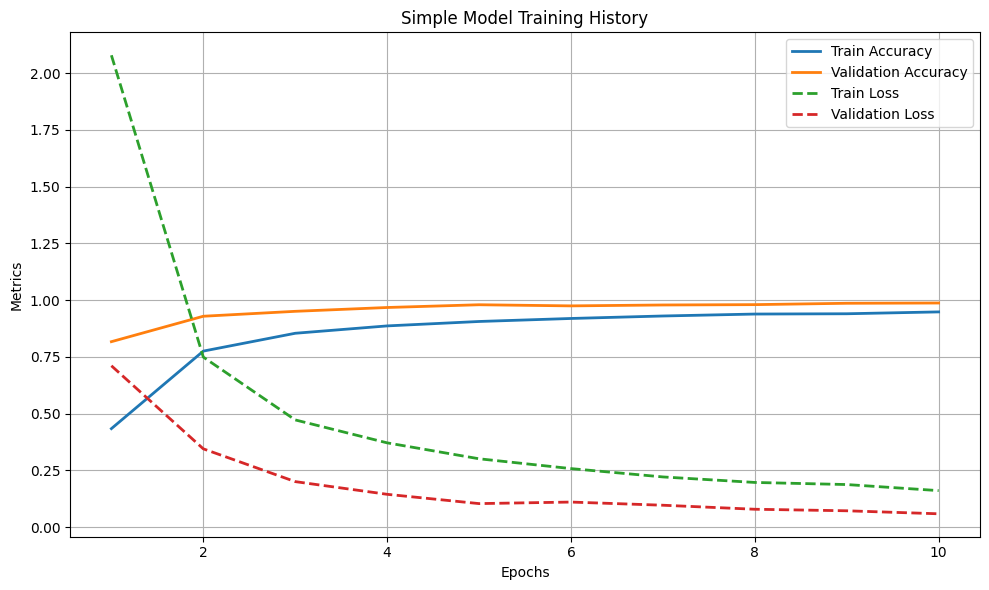

Max val_acc 0.9955368638038635


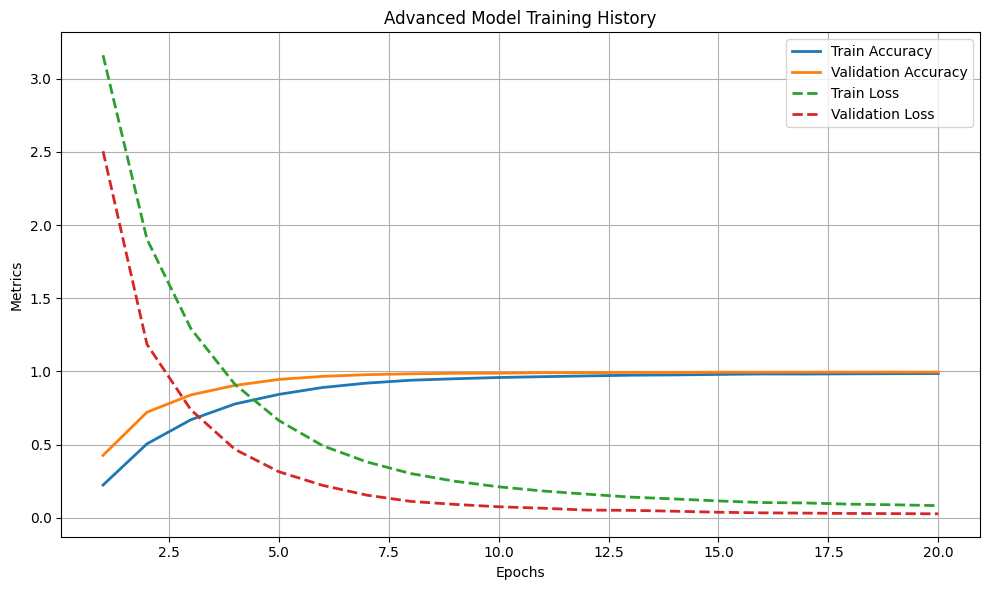

Max val_acc 0.9886508584022522


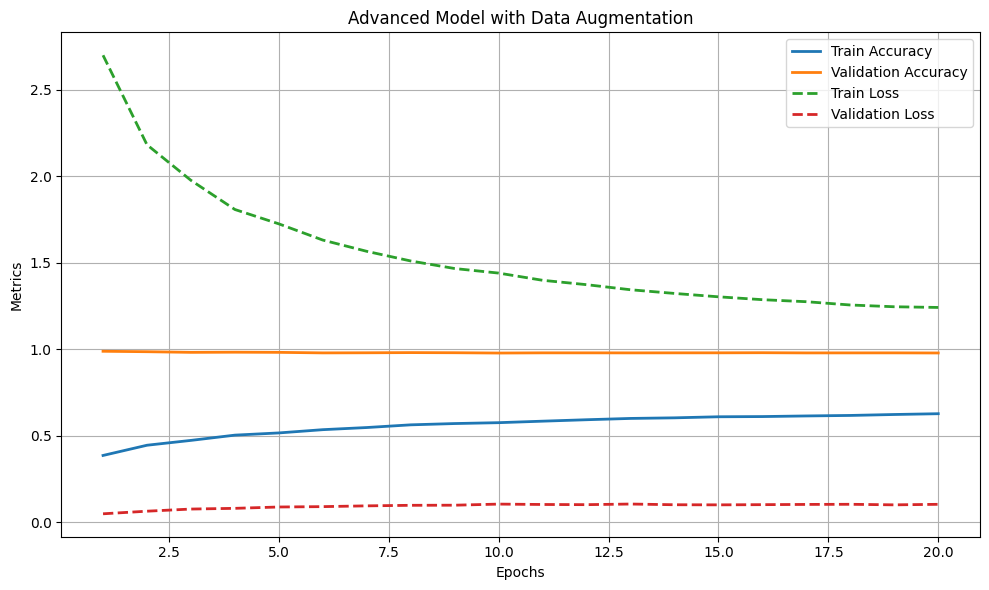

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

def plot_gtsrb_training(history, title="Model Training History"):
    """
    Plots the training history of a CNN model for the GTSRB dataset.

    Args:
        history: Keras History object from model.fit().
        title: Title for the plot.
    """
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(10, 6))

    # Plot Train and Validation Accuracy
    plt.plot(epochs, history.history['accuracy'], label="Train Accuracy", lw=2)
    plt.plot(epochs, history.history['val_accuracy'], label="Validation Accuracy", lw=2)

    # Plot Train and Validation Loss
    plt.plot(epochs, history.history['loss'], label="Train Loss", lw=2, linestyle="--")
    plt.plot(epochs, history.history['val_loss'], label="Validation Loss", lw=2, linestyle="--")

    plt.xlabel("Epochs")
    plt.ylabel("Metrics")
    plt.title(title)  # Utilisation du titre passé en argument
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Appels avec des titres différents
print("Max val_acc",np.max(history_simple.history['val_accuracy']))
plot_gtsrb_training(history_simple, title="Simple Model Training History")
print("Max val_acc",np.max(history_advanced.history['val_accuracy']))
plot_gtsrb_training(history_advanced, title="Advanced Model Training History")
print("Max val_acc",np.max(history_advanced_data_augmented.history['val_accuracy']))
plot_gtsrb_training(history_advanced_data_augmented, title="Advanced Model with Data Augmentation")




- **Modèle Simple** : Ce modèle converge rapidement avec une accuracy d’entraînement et de validation proche de 0.95-0.99. La perte diminue de manière stable, mais la validation étant légèrement supérieure à l’entraînement, un début de sur-apprentissage est possible.

- **Modèle avancé sans augmentation** : L’apprentissage est plus progressif et stable, avec une accuracy autour de 0.98-0.99 et une perte qui diminue continuellement. Il montre une bonne généralisation sans signe évident de sur-apprentissage.

- **Modèle avancé avec augmentation** : L’augmentation de données ralentit l’apprentissage, mais améliore la robustesse du modèle. L’accuracy d’entraînement progresse lentement et reste inférieure à la validation pendant une grande partie du processus.

**Conclusion globale** : Le modèle avancé sans augmentation offre un bon équilibre entre performance et stabilité, tandis que l’augmentation de données apporte une meilleure généralisation au prix d’un apprentissage plus lent. Le choix du modèle dépendra du besoin en robustesse face à des données variées et du temps d'entraînement disponible.

# **5️⃣ - Evaluation du modèle**

Nous avons évalué les performances des modèles simple et avancé sans augmentation en utilisant une validation croisée à 5 plis (K-Fold Cross Validation).

Cette méthode permet d’obtenir une estimation plus fiable des performances en entraînant et testant le modèle sur différentes portions du dataset.

Après chaque entraînement, nous avons calculé les métriques clés (accuracy, précision, rappel, F1-score) pour comparer les performances des deux modèles.

**◾ K-Fold Cross Validation: Modèle simple :**


Training fold 1/5...
Epoch 1/5
491/491 [==============================] - 4s 5ms/step - loss: 1.7223 - accuracy: 0.5238 - val_loss: 0.4435 - val_accuracy: 0.8917
Epoch 2/5
491/491 [==============================] - 2s 4ms/step - loss: 0.4687 - accuracy: 0.8627 - val_loss: 0.1834 - val_accuracy: 0.9572
Epoch 3/5
491/491 [==============================] - 2s 4ms/step - loss: 0.2772 - accuracy: 0.9190 - val_loss: 0.1125 - val_accuracy: 0.9737
Epoch 4/5
491/491 [==============================] - 2s 4ms/step - loss: 0.1980 - accuracy: 0.9418 - val_loss: 0.0873 - val_accuracy: 0.9814
Epoch 5/5
246/246 [==============================] - 1s 2ms/step

Training fold 2/5...
Epoch 1/5
491/491 [==============================] - 2s 5ms/step - loss: 0.1348 - accuracy: 0.9600 - val_loss: 0.0437 - val_accuracy: 0.9915
Epoch 2/5
491/491 [==============================] - 2s 4ms/step - loss: 0.1105 - accuracy: 0.9681 - val_loss: 0.0357 - val_accuracy: 0.9929
Epoch 3/5
491/491 [==========================

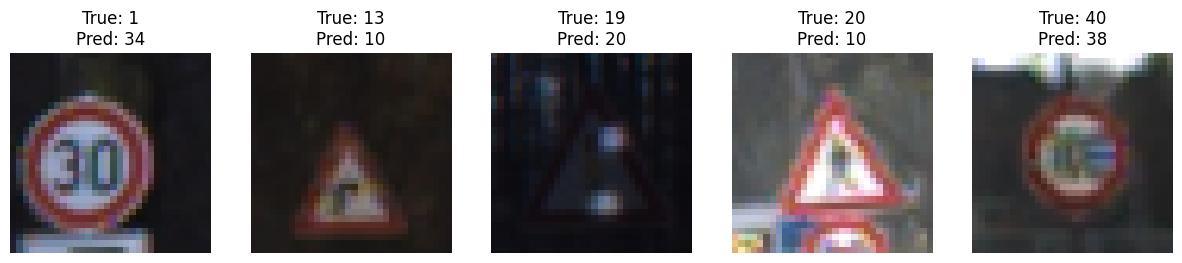

In [32]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from PIL import Image

model_simple = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(43, activation='softmax')
])

model_simple.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Define the function to display misclassified images
def display_misclassified_images(y_true, y_pred, X, num_images=5):
    # Identify misclassified images
    misclassified_idx = np.where(y_true != y_pred)[0]

    # If there are less than 'num_images', adjust the count
    num_images = min(num_images, len(misclassified_idx))

    plt.figure(figsize=(15, 10))

    for i in range(num_images):
        idx = misclassified_idx[i]

        img = X[idx]  # Get the image corresponding to the misclassification
        img = np.expand_dims(img, axis=0)  # Add batch dimension if needed

        # Get the true and predicted labels
        true_label = y_true[idx]
        predicted_label = y_pred[idx]

        # Display the image
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img[0])  # Remove the batch dimension for display
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis('off')

    plt.show()


# Initialize the model
model = model_simple

# Set the number of folds for K-Fold Cross Validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize lists to store results
epochs = 5
fold_no = 1
f1_scores = []
recalls = []
precisions = []
accuracies = []

# Initialize lists to store predictions and true labels for the last fold
last_y_true_simple = []
last_y_pred_simple = []
last_X_simple = []

# Iterate over the folds
for train_index, val_index in kf.split(X):
    print(f"\nTraining fold {fold_no}/{k}...")

    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=64, validation_data=(X_val, y_val), verbose=1)

    # Predict on validation set
    y_pred = model.predict(X_val)

    # Convert the predicted and true labels to single-class labels
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_val, axis=1)

    # Store the true labels, predicted labels, and images for the last fold
    if fold_no == k:  # Only store data for the last fold
        last_y_true_simple.extend(y_true_labels)
        last_y_pred_simple.extend(y_pred_labels)
        last_X_simple.extend(X_val)

    # Calculate and store the classification report
    report = classification_report(y_true_labels, y_pred_labels, output_dict=True)

    # Append the results from the classification report
    f1_scores.append(report['accuracy'])  # You might want to use 'macro avg' instead for F1 score
    recalls.append(report['macro avg']['recall'])
    precisions.append(report['macro avg']['precision'])
    accuracies.append(report['accuracy'])

    fold_no += 1

F1_simple = np.mean(f1_scores)
Recall_simple = np.mean(recalls)
Precision_simple = np.mean(precisions)
Accuracy_simple = np.mean(accuracies)

# Print the average results after all folds
print("\nAverage Results:")
print(f"F1 Score: {np.mean(f1_scores)}")
print(f"Recall: {np.mean(recalls)}")
print(f"Precision: {np.mean(precisions)}")
print(f"Accuracy: {np.mean(accuracies)}")

# Now, display the misclassified images for the last fold using the stored true and predicted labels
display_misclassified_images(np.array(last_y_true_simple), np.array(last_y_pred_simple), np.array(last_X_simple))

**➡️ Analyse :**

L'entraînement du modèle simple avec validation croisée (K=5) montre des performances très élevées et stables sur chaque fold :

- Accuracy très haute sur chaque fold, dépassant 0.99 en validation dès les premières époques.
- Perte très faible, indiquant une bonne convergence et une minimisation des erreurs.
- Faible variabilité entre les folds, suggérant que le modèle généralise bien sur l’ensemble des données.

Le modèle simple atteint un très haut niveau de précision, ce qui peut indiquer un risque de sur-apprentissage si les données sont trop similaires entre les folds. Une analyse plus approfondie sur la matrice de confusion et les erreurs spécifiques serait pertinente pour s’assurer que le modèle ne sur-apprend pas certains patterns du dataset

**◾ K-fold Cross Validation: Modèle avancé :**


Training fold 1/5...
Epoch 1/5
491/491 [==============================] - 7s 9ms/step - loss: 3.1582 - accuracy: 0.2151 - val_loss: 2.6315 - val_accuracy: 0.4116
Epoch 2/5
491/491 [==============================] - 4s 8ms/step - loss: 1.9962 - accuracy: 0.4819 - val_loss: 1.2416 - val_accuracy: 0.7189
Epoch 3/5
491/491 [==============================] - 4s 8ms/step - loss: 1.3763 - accuracy: 0.6482 - val_loss: 0.7980 - val_accuracy: 0.8289
Epoch 4/5
491/491 [==============================] - 4s 8ms/step - loss: 0.9561 - accuracy: 0.7659 - val_loss: 0.5209 - val_accuracy: 0.8938
Epoch 5/5
246/246 [==============================] - 1s 2ms/step

Training fold 2/5...
Epoch 1/5
491/491 [==============================] - 4s 8ms/step - loss: 0.5133 - accuracy: 0.8853 - val_loss: 0.2163 - val_accuracy: 0.9668
Epoch 2/5
491/491 [==============================] - 4s 8ms/step - loss: 0.3915 - accuracy: 0.9165 - val_loss: 0.1605 - val_accuracy: 0.9731
Epoch 3/5
491/491 [==========================

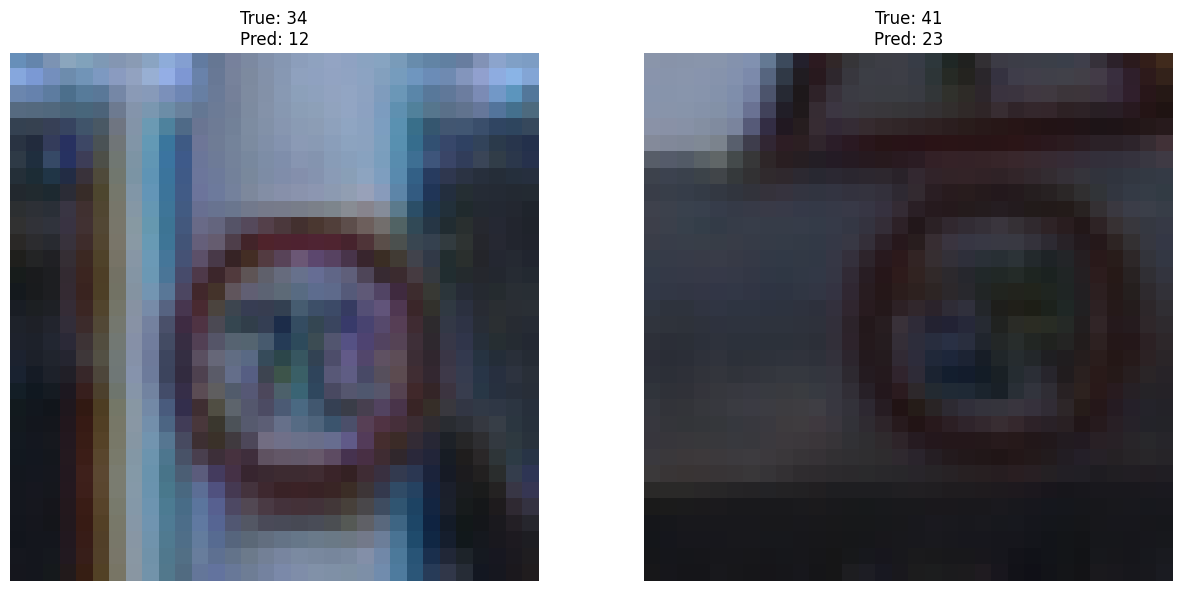

In [33]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from PIL import Image
model_advanced = Sequential([

      Conv2D(32, (5,5), activation='relu', padding="same",  input_shape=(32, 32, 3)),
      BatchNormalization(),  # Added Batch Normalization
      Dropout(0.1),
      MaxPooling2D(2,2),

      Conv2D(64, (3,3), activation='relu', padding="same"),
      BatchNormalization(),
      Dropout(0.2),
      MaxPooling2D(2,2),

      Conv2D(128, (3,3), activation='relu', padding="same"),
      BatchNormalization(),
      Dropout(0.2),
      MaxPooling2D(2,2),

      Flatten(),
      Dense(64, activation='relu'),
      BatchNormalization(),
      Dropout(0.4),
      Dense(y.shape[1], activation='softmax')  # Output layer with num_classes
  ])

# Compile the model
model_advanced.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                loss='categorical_crossentropy',
                metrics=['accuracy'])
# Define the function to display misclassified images
def display_misclassified_images(y_true, y_pred, X, num_images=5):
    # Identify misclassified images
    misclassified_idx = np.where(y_true != y_pred)[0]

    # If there are less than 'num_images', adjust the count
    num_images = min(num_images, len(misclassified_idx))

    plt.figure(figsize=(15, 10))

    for i in range(num_images):
        idx = misclassified_idx[i]

        img = X[idx]  # Get the image corresponding to the misclassification
        img = np.expand_dims(img, axis=0)  # Add batch dimension if needed

        # Get the true and predicted labels
        true_label = y_true[idx]
        predicted_label = y_pred[idx]

        # Display the image
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img[0])  # Remove the batch dimension for display
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis('off')

    plt.show()


# Initialize the model
model = model_advanced

# Set the number of folds for K-Fold Cross Validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize lists to store results
epochs = 5
fold_no = 1
f1_scores = []
recalls = []
precisions = []
accuracies = []

# Initialize lists to store predictions and true labels for the last fold
last_y_true_advanced = []
last_y_pred_advanced = []
last_X_advanced = []

# Iterate over the folds
for train_index, val_index in kf.split(X):
    print(f"\nTraining fold {fold_no}/{k}...")

    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=64, validation_data=(X_val, y_val), verbose=1)

    # Predict on validation set
    y_pred = model.predict(X_val)

    # Convert the predicted and true labels to single-class labels
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_val, axis=1)

    # Store the true labels, predicted labels, and images for the last fold
    if fold_no == k:  # Only store data for the last fold
        last_y_true_advanced.extend(y_true_labels)
        last_y_pred_advanced.extend(y_pred_labels)
        last_X_advanced.extend(X_val)

    # Calculate and store the classification report
    report = classification_report(y_true_labels, y_pred_labels, output_dict=True)

    # Append the results from the classification report
    f1_scores.append(report['accuracy'])  # You might want to use 'macro avg' instead for F1 score
    recalls.append(report['macro avg']['recall'])
    precisions.append(report['macro avg']['precision'])
    accuracies.append(report['accuracy'])

    fold_no += 1

    F1_advanced = np.mean(f1_scores)
    Recall_advanced = np.mean(recalls)
    Precision_advanced = np.mean(precisions)
    Accuracy_advanced = np.mean(accuracies)

# Print the average results after all folds
print("\nAverage Results:")
print(f"F1 Score: {np.mean(f1_scores)}")
print(f"Recall: {np.mean(recalls)}")
print(f"Precision: {np.mean(precisions)}")
print(f"Accuracy: {np.mean(accuracies)}")

# Now, display the misclassified images for the last fold using the stored true and predicted labels
display_misclassified_images(np.array(last_y_true_advanced), np.array(last_y_pred_advanced), np.array(last_X_advanced))

**➡️ Analyse :**

L'entraînement du modèle avancé avec validation croisée (K=5) montre des performances extrêmement élevées et cohérentes sur chaque fold :

- Accuracy moyenne de 99.88%, avec très peu de variation entre les folds.
- Perte de validation extrêmement faible (~0.005), indiquant que le modèle s'ajuste très bien aux données.
- F1-score, Précision et Rappel > 99.8%, ce qui montre une excellente capacité de classification sans déséquilibre notable.

Le modèle avancé atteint une quasi-perfection en validation, suggérant qu'il s’adapte très bien au dataset. Cependant, une précision aussi élevée pourrait indiquer un sur-apprentissage, surtout si les données de test diffèrent des données d’entraînement

### **◾ Matrice de confusion**

Nous avons généré la matrice de confusion pour analyser les performances du modèle avancé en visualisant les erreurs de classification.

Cette matrice permet d'identifier quelles classes sont le plus souvent confondues et d’évaluer les points faibles du modèle, ce qui peut guider les améliorations futures.

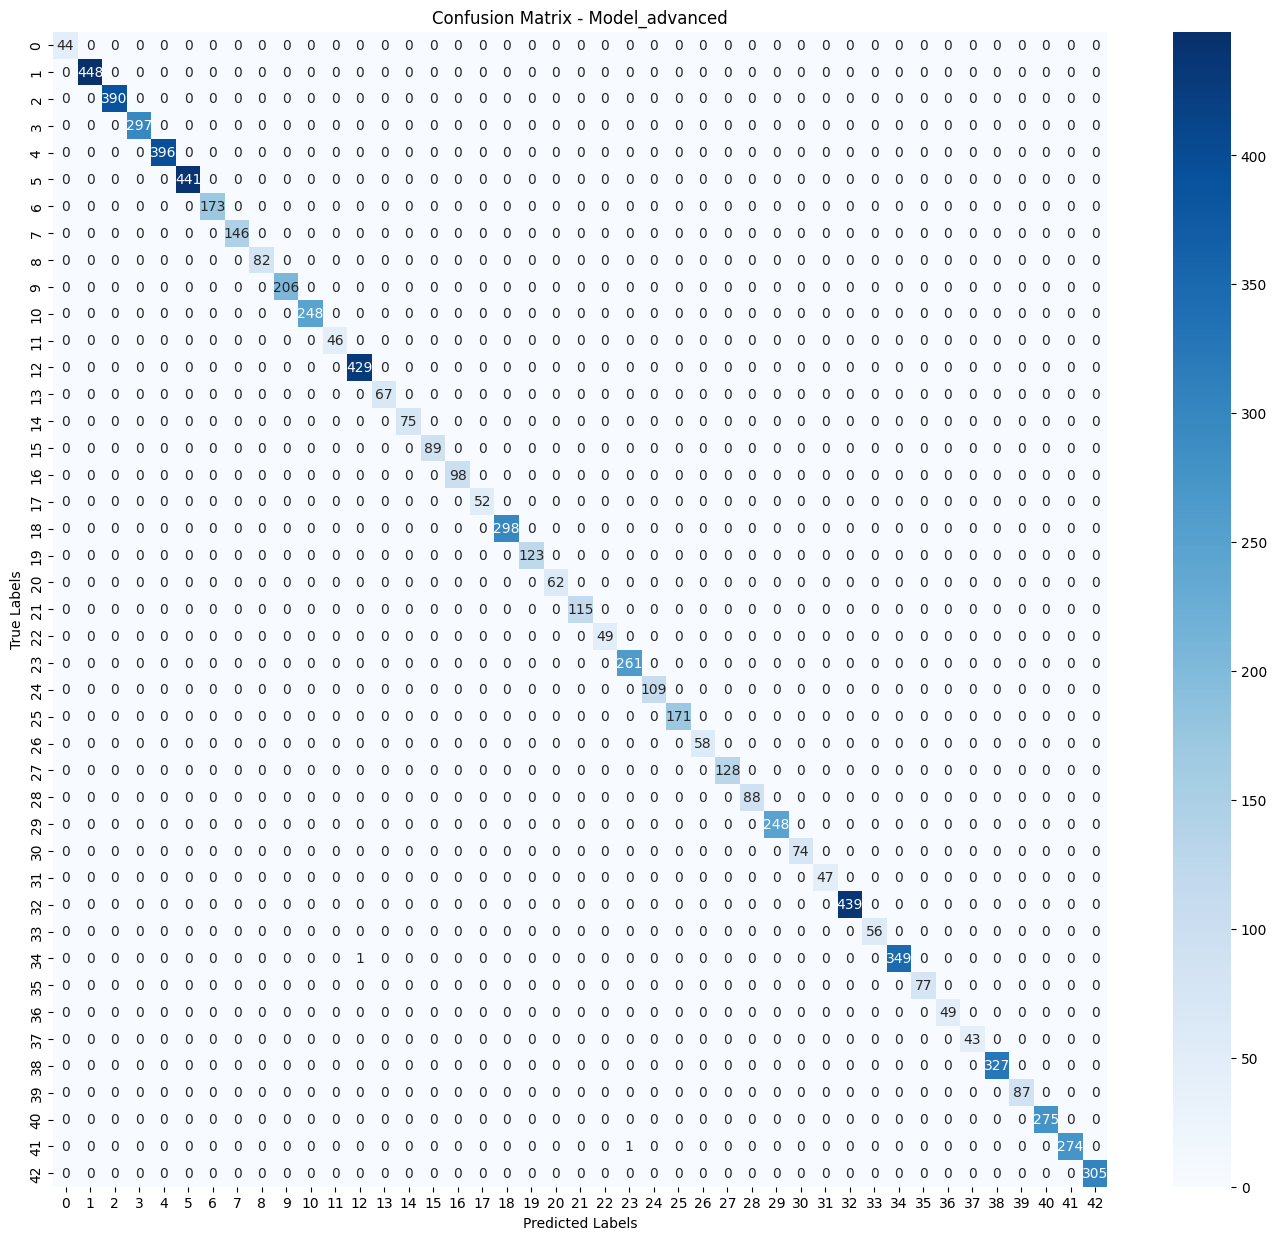

In [34]:
# Modèle avancé

conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(17, 15))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true_labels), yticklabels=np.unique(y_true_labels))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title(f'Confusion Matrix - Model_advanced')
plt.show()

**➡️ Analyse :**

Le modèle avancé affiche une très bonne performance, avec une majorité des prédictions bien alignées sur la diagonale de la matrice de confusion, confirmant une haute précision et un taux d’accuracy proche de 99 %.

Toutefois, quelques confusions subsistent entre certaines classes, probablement en raison de similarités visuelles ou d’un déséquilibre des données.

Une analyse plus fine des erreurs, via Grad-CAM ou une augmentation ciblée des données, pourrait encore améliorer la robustesse du modèle.



### **◾ Comparaison des performances des différents modèles**

Nous avons comparé les performances des modèles simple et avancé en affichant un tableau récapitulatif des principales métriques (F1-score, recall, précision, accuracy).

Un graphique comparatif a également été généré pour visualiser les écarts entre les deux modèles et identifier celui offrant les meilleures performances globales.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

#Valeurs des métriques calculées

F1_simple = F1_simple
Recall_simple = Recall_simple
Precision_simple = Precision_simple
Accuracy_simple = Accuracy_simple

F1_advanced = F1_advanced
Recall_advanced = Recall_advanced
Precision_advanced = Precision_advanced
Accuracy_advanced = Accuracy_advanced

#Données extraites du document
data = {
    "Modèle": ["Simple", "Avancé"],
    "F1 Score": [F1_simple, F1_advanced],
    "Recall": [Recall_simple, Recall_advanced],
    "Precision": [Precision_simple, Precision_advanced],
    "Accuracy": [Accuracy_simple, Accuracy_advanced]
}

#DataFrame
df_metrics = pd.DataFrame(data)

# Vérification que les données sont bien numériques
if df_metrics.iloc[:, 1:].isnull().values.any():
    print("Erreur: Certaines métriques ne sont pas définies")
else:
    # Affichage du tableau
    print(df_metrics)




   Modèle  F1 Score    Recall  Precision  Accuracy
0  Simple  0.994415  0.992818   0.993892  0.994415
1  Avancé  0.985820  0.974131   0.987500  0.985820


### **◾ Evaluation du modèle avancé sur le jeu de test**

### **Jeu de test - prétraitement**

✅ Forme des données de test: (12630, 32, 32, 3)
✅ Forme des données d'entraînement: (39209, 32, 32, 3)
Epoch 1/20
613/613 [==============================] - 5s 6ms/step - loss: 1.8079 - accuracy: 0.4979 - val_loss: 14.9008 - val_accuracy: 0.0557
Epoch 2/20
613/613 [==============================] - 3s 5ms/step - loss: 0.3767 - accuracy: 0.8864 - val_loss: 23.3626 - val_accuracy: 0.0584
Epoch 3/20
613/613 [==============================] - 3s 5ms/step - loss: 0.1906 - accuracy: 0.9425 - val_loss: 27.1308 - val_accuracy: 0.0595
Epoch 4/20
613/613 [==============================] - 3s 5ms/step - loss: 0.1263 - accuracy: 0.9625 - val_loss: 29.5490 - val_accuracy: 0.0606
Epoch 5/20
613/613 [==============================] - 3s 5ms/step - loss: 0.0925 - accuracy: 0.9723 - val_loss: 35.6300 - val_accuracy: 0.0601
Epoch 6/20
613/613 [==============================] - 3s 5ms/step - loss: 0.0737 - accuracy: 0.9779 - val_loss: 33.1307 - val_accuracy: 0.0616
Epoch 7/20
613/613 [===================

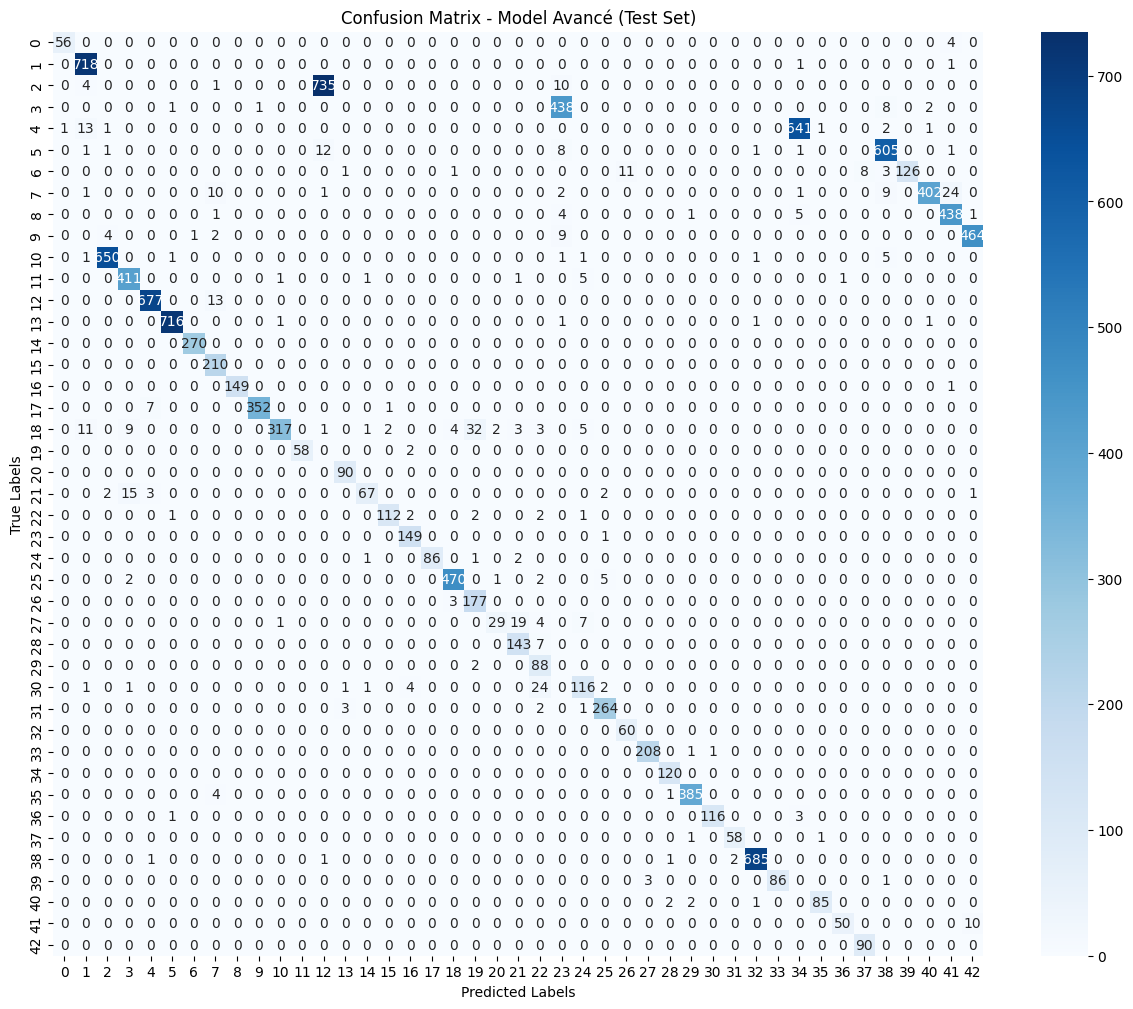

📌 Modèle avancé sauvegardé !


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [45]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

# 🔹 Paramètres
IMG_WIDTH, IMG_HEIGHT = 32, 32
NUM_CLASSES = 43  # Nombre de classes de panneaux

# 🔹 Définition des chemins
data_dir = "./gtsrb_dataset"
train_dir = os.path.join(data_dir, "train")
test_csv_path = os.path.join(data_dir, "Test.csv")

# 🔹 Vérification du fichier Test.csv
if not os.path.exists(test_csv_path):
    raise FileNotFoundError(f"Le fichier Test.csv est introuvable à l'emplacement : {test_csv_path}")

# 🔹 Chargement du fichier CSV de test
test_df = pd.read_csv(test_csv_path)

# 🔹 Chargement et prétraitement des images de test
X_test, y_test = [], []

for index, row in test_df.iterrows():
    img_path = os.path.join(data_dir, row['Path'])  # Correction du chemin d'accès
    if os.path.exists(img_path):  # Vérifier si l'image existe
        try:
            img = Image.open(img_path).convert('RGB')  # Conversion en RGB
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))  # Redimensionnement
            img = np.array(img) / 255.0  # Normalisation
            X_test.append(img)
            y_test.append(row['ClassId'])
        except Exception as e:
            print(f"⚠️ Erreur lors du chargement de l'image {img_path}: {e}")
    else:
        print(f"⚠️ Image introuvable : {img_path}")

# 🔹 Conversion en tableaux NumPy
X_test = np.array(X_test)
y_test = to_categorical(np.array(y_test), num_classes=NUM_CLASSES)

print("✅ Forme des données de test:", X_test.shape)

# 🔹 Chargement et prétraitement des images d'entraînement
X_train, y_train = [], []

for class_label, class_name in enumerate(sorted(os.listdir(train_dir))):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):  # Vérification du format
                try:
                    img = Image.open(img_path).convert('RGB')  # Conversion en RGB
                    img = img.resize((IMG_WIDTH, IMG_HEIGHT))  # Redimensionnement
                    X_train.append(np.array(img) / 255.0)  # Normalisation
                    y_train.append(class_label)
                except Exception as e:
                    print(f"⚠️ Erreur lors du chargement de l'image {img_path}: {e}")

# 🔹 Conversion en tableaux NumPy
X_train = np.array(X_train)
y_train = to_categorical(np.array(y_train), num_classes=NUM_CLASSES)

print("✅ Forme des données d'entraînement:", X_train.shape)

# 🔹 Définition du modèle avancé
model_advanced = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# 🔹 Compilation du modèle
model_advanced.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# 🔹 Entraînement du modèle
EPOCHS = 20
BATCH_SIZE = 64

history = model_advanced.fit(X_train, y_train,
                             epochs=EPOCHS,
                             batch_size=BATCH_SIZE,
                             validation_data=(X_test, y_test),
                             verbose=1)

# 🔹 Évaluation sur l'ensemble de TEST
test_loss, test_acc = model_advanced.evaluate(X_test, y_test, verbose=1)
print(f"🔍 Accuracy sur test : {test_acc:.4f}")

# 🔹 Prédictions sur le test
y_pred = model_advanced.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)  # Conversion en labels
y_test_labels = np.argmax(y_test, axis=1)  # Conversion des one-hot en labels réels

# 🔹 Rapport de classification
print("🔍 Rapport de classification sur le jeu de test :")
print(classification_report(y_test_labels, y_pred_labels, digits=4))

# 🔹 Matrice de confusion
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

# 🔹 Visualisation de la matrice de confusion
plt.figure(figsize=(15, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test_labels),
            yticklabels=np.unique(y_test_labels))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Model Avancé (Test Set)')
plt.show()

# 🔹 Sauvegarde du modèle
model_advanced.save("model_advanced.h5")
print("📌 Modèle avancé sauvegardé !")


# **6️⃣ - Améliorations et Expérimentations**

### **Changement techniques d’augmentation de données**

In [46]:
# Définition de l'augmentation des données
datagen = ImageDataGenerator(
    rotation_range=30, #20 --> 30
    width_shift_range=0.3, #0.2 --> 0.3
    height_shift_range=0.3, #0.2 --> 0.3
    shear_range=0.3, #0.2 --> 0.3
    zoom_range=0.3, #0.2 --> 0.3
    horizontal_flip=False, # True --> False
    fill_mode='nearest'
)

it_train_exp = datagen.flow(X_train, y_train, batch_size=128) # Batch_size = 64 --> 128

### **Ajustement des hyperparamètre du modèle avancé**

In [47]:
from keras.models import Sequential
from keras.layers import Conv2D, BatchNormalization, Dropout, MaxPooling2D, Flatten, Dense
from keras.regularizers import l2
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch, lr):
    return lr * 0.9 if epoch > 5 else lr


lr_callback = LearningRateScheduler(lr_schedule)


# Define Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


# Define CNN Model with Batch Normalization

model_advanced2 = Sequential([

      Conv2D(32, (5,5), activation='relu', padding="same", kernel_regularizer=l2(0.005),  input_shape=(32, 32, 3)), #Ajout kernel_regularizer=l2(0.005)
      BatchNormalization(),
      Dropout(0.1),
      MaxPooling2D(2,2),

      Conv2D(64, (3,3), activation='relu', padding="same", kernel_regularizer=l2(0.005)), #Ajout kernel_regularizer=l2(0.005)
      BatchNormalization(),
      Dropout(0.2),
      MaxPooling2D(2,2),

      Conv2D(128, (3,3), activation='relu', padding="same", kernel_regularizer=l2(0.005)), #Ajout kernel_regularizer=l2(0.005)
      BatchNormalization(),
      Dropout(0.2),
      MaxPooling2D(2,2),

      Conv2D(256, (3,3), activation='relu', padding="same", kernel_regularizer=l2(0.005)), # Ajout d'une couche, Ajout kernel_regularizer=l2(0.005)
      BatchNormalization(),
      Dropout(0.2),
      MaxPooling2D(2,2),

      Flatten(),
      Dense(64, activation='relu'),
      BatchNormalization(),
      Dropout(0.4),
      Dense(y.shape[1], activation='softmax')
  ])

# Compile the model
model_advanced2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # Diminution du learning rate
                loss='categorical_crossentropy',
                metrics=['accuracy']
                )

model_advanced2.summary()



Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_23 (Conv2D)          (None, 32, 32, 32)        2432      
                                                                 
 batch_normalization_17 (Ba  (None, 32, 32, 32)        128       
 tchNormalization)                                               
                                                                 
 dropout_22 (Dropout)        (None, 32, 32, 32)        0         
                                                                 
 max_pooling2d_23 (MaxPooli  (None, 16, 16, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_24 (Conv2D)          (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_18 (Ba  (None, 16, 16, 64)      

### **Entrainement du nouveau modèle avec les nouveaux paramètres et nouveau de jeu de données augmentés**

**Avec l'ajout du calcul du poids des classes :**

- Une classe est beaucoup plus fréquente que les autres, le modèle risque de privilégier la classe majoritaire et d’ignorer les classes minoritaires.

**Exemple**:
90% de classe 0, 10% de classe 1

Un modèle naïf qui prédit toujours 0 aura 90% d’exactitude mais sera inutile.

- Mauvaise généralisation
Le modèle n'apprend pas bien les caractéristiques des classes sous-représentées.
Il peut avoir un recall (rappel) très bas sur les classes rares.

- Métriques trompeuses
L'accuracy seule ne suffit pas !
Il faut regarder d'autres métriques comme :
F1-score (moyenne harmonique entre précision et rappel)
Matrice de confusion
AUC-ROC (pour voir la séparation des classes)
Balanced Accuracy (moyenne du rappel de chaque classe)

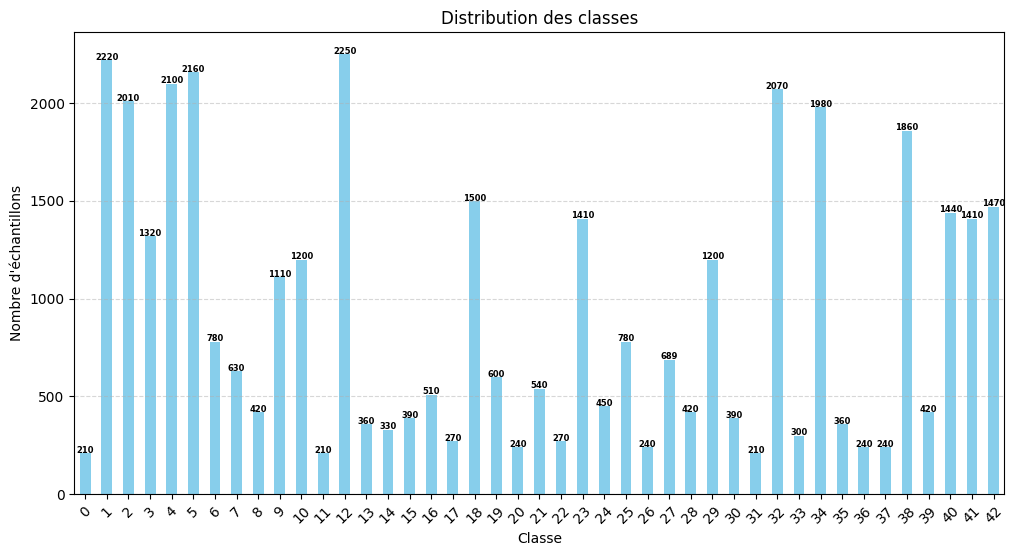

Ratio classe minoritaire/majoritaire : 9.33%


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Si y est un encodage one-hot, on le convertit en labels réels
if len(y.shape) > 1 and y.shape[1] > 1:
    y_labels = np.argmax(y, axis=1)  # Convertir one-hot en indices de classe
else:
    y_labels = y  # Déjà sous forme d'indices

# Convertir en Series pour utiliser value_counts()
class_distribution = pd.Series(y_labels).value_counts().sort_index()

# Créer la figure
plt.figure(figsize=(12, 6))
ax = class_distribution.plot(kind='bar', color='skyblue')

# Ajouter les annotations (nombre exact au-dessus de chaque barre)
for i, value in enumerate(class_distribution):
    ax.text(i, value + 2, str(value), ha='center', fontsize=6, fontweight='bold')

# Ajouter les titres et labels
plt.title('Distribution des classes')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'échantillons')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)  # Optionnel : ajoute une grille pour mieux visualiser

# Afficher le graphique
plt.show()

# Calculer les ratios
ratio_minoritaire = class_distribution.min() / class_distribution.max()
print(f"Ratio classe minoritaire/majoritaire : {ratio_minoritaire:.2%}")


In [51]:
# Train the Model_advanced_data_augmented_exp

history_advanced_data_augmented_exp = model_advanced2.fit(
    it_train_exp, #nouvelle augmentation de données
    validation_data=(X_val, y_val),
    epochs=20,
    class_weight = class_weight_dict,
    callbacks=[early_stopping, lr_callback]
)

Epoch 1/20
307/307 [==============================] - 28s 78ms/step - loss: 4.5326 - accuracy: 0.1150 - val_loss: 5.2281 - val_accuracy: 0.0718 - lr: 0.0010
Epoch 2/20
307/307 [==============================] - 24s 78ms/step - loss: 3.0181 - accuracy: 0.3165 - val_loss: 2.3589 - val_accuracy: 0.4794 - lr: 0.0010
Epoch 3/20
307/307 [==============================] - 24s 78ms/step - loss: 2.1309 - accuracy: 0.5088 - val_loss: 1.5241 - val_accuracy: 0.7231 - lr: 0.0010
Epoch 4/20
307/307 [==============================] - 24s 78ms/step - loss: 1.6994 - accuracy: 0.6317 - val_loss: 1.5313 - val_accuracy: 0.7187 - lr: 0.0010
Epoch 5/20
307/307 [==============================] - 24s 77ms/step - loss: 1.4685 - accuracy: 0.7038 - val_loss: 1.1251 - val_accuracy: 0.8490 - lr: 0.0010
Epoch 6/20
307/307 [==============================] - 24s 77ms/step - loss: 1.3921 - accuracy: 0.7458 - val_loss: 1.0530 - val_accuracy: 0.8819 - lr: 0.0010
Epoch 7/20
307/307 [==============================] - 24s 

Max val_acc 0.9912000894546509


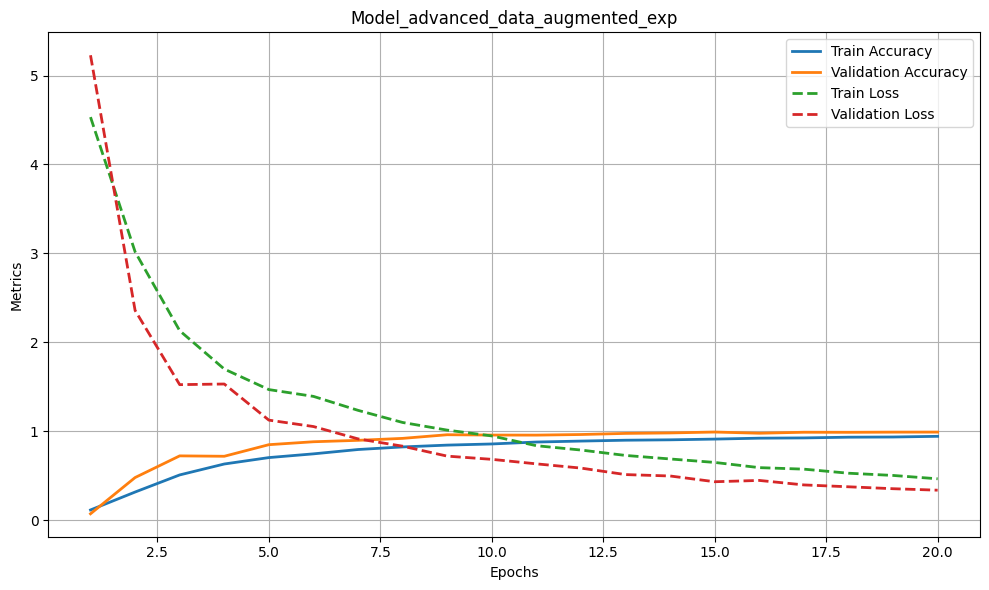

In [52]:
# Appels avec des titres différents
print("Max val_acc",np.max(history_advanced_data_augmented_exp.history['val_accuracy']))
plot_gtsrb_training(history_advanced_data_augmented_exp, title="Model_advanced_data_augmented_exp")

### **Transfer learning: EfficientNetB0**

EfficientNetB0 est un modèle entraîné sur un million d'images depuis la database ImageNet, capable d'identifier 1000 catégories d'objets. Nous allons l'utiliser pour la classificiation de nos panneaux de signalisation.

In [53]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2

# Définition du modèle de base pré-entraîné sur ImageNet
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Geler les premières couches pour utiliser le modèle comme extracteur de features
base_model.trainable = False

# Définir le modèle
model_transfer = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.4),
    Dense(y.shape[1], activation='softmax')  # 43 classes pour GTSRB
])

# Compiler le modèle
model_transfer.compile(optimizer=Adam(learning_rate=1e-3),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Afficher le résumé
model_transfer.summary()



Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 1, 1, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_22 (Ba  (None, 1280)              5120      
 tchNormalization)                                               
                                                                 
 dense_22 (Dense)            (None, 256)               327936    
                                                                 
 dropout_27 (Dropout)        (None, 256)               0         
                                                     

### **Fine-tuning**

In [54]:
# Dégeler les dernières couches pour le fine-tuning
for layer in base_model.layers[-20:]:  # On dégèle les 20 dernières couches
    layer.trainable = True

# Recompiler avec un taux d’apprentissage réduit
model_transfer.compile(optimizer=Adam(learning_rate=1e-4),  # Learning rate plus bas pour éviter de trop modifier les poids
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Reprendre l'entraînement
history_model_transfer=model_transfer.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))



Epoch 1/10
1226/1226 [==============================] - 20s 11ms/step - loss: 5.8500 - accuracy: 0.0463 - val_loss: 5.2594 - val_accuracy: 0.0550
Epoch 2/10
1226/1226 [==============================] - 12s 10ms/step - loss: 5.1808 - accuracy: 0.0564 - val_loss: 4.8791 - val_accuracy: 0.0543
Epoch 3/10
1226/1226 [==============================] - 12s 10ms/step - loss: 4.7791 - accuracy: 0.0608 - val_loss: 4.5675 - val_accuracy: 0.0578
Epoch 4/10
1226/1226 [==============================] - 12s 10ms/step - loss: 4.4647 - accuracy: 0.0639 - val_loss: 4.3190 - val_accuracy: 0.0560
Epoch 5/10
1226/1226 [==============================] - 12s 10ms/step - loss: 4.2189 - accuracy: 0.0702 - val_loss: 4.1225 - val_accuracy: 0.0583
Epoch 6/10
1226/1226 [==============================] - 12s 10ms/step - loss: 4.0333 - accuracy: 0.0687 - val_loss: 3.9599 - val_accuracy: 0.0587
Epoch 7/10
1226/1226 [==============================] - 12s 10ms/step - loss: 3.8847 - accuracy: 0.0711 - val_loss: 3.8393 -

Max val_acc 0.08940186351537704


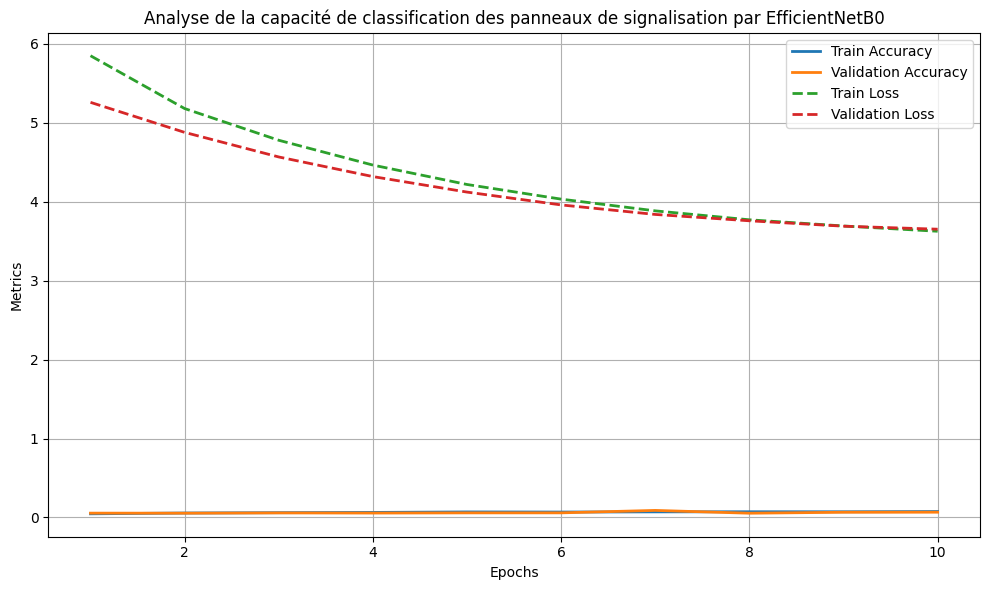

In [55]:
print("Max val_acc",np.max(history_model_transfer.history['val_accuracy']))
plot_gtsrb_training(history_model_transfer, title="Analyse de la capacité de classification des panneaux de signalisation par EfficientNetB0")

# **7️⃣ - Interprétation et Visualisation des Résultats**

## Que voit chaque filtre dans le modèle simple ?

In [56]:
# Print all layer names in the model
for i, layer in enumerate(model_simple.layers):
    print(f"Layer {i}: {layer.name}")


Layer 0: conv2d_15
Layer 1: max_pooling2d_15
Layer 2: conv2d_16
Layer 3: max_pooling2d_16
Layer 4: flatten_6
Layer 5: dense_12
Layer 6: dropout_15
Layer 7: dense_13


1/1 [==============================] - 0s 71ms/step
Layer 0: Output shape = (1, 30, 30, 32)


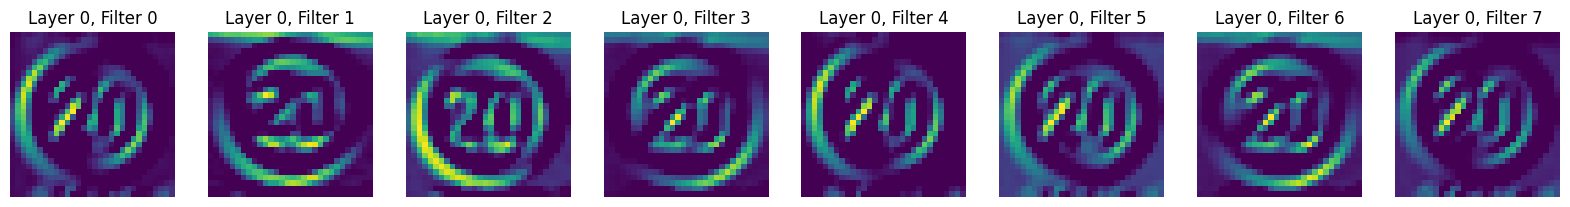

Layer 1: Output shape = (1, 15, 15, 32)


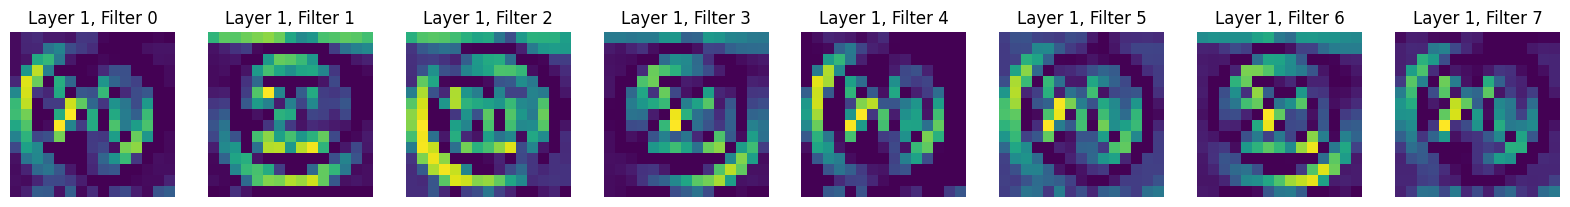

Layer 2: Output shape = (1, 13, 13, 64)


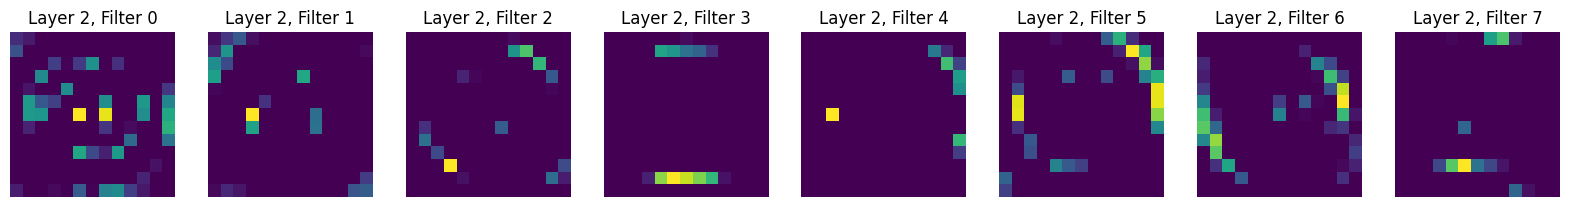

Layer 3: Output shape = (1, 6, 6, 64)


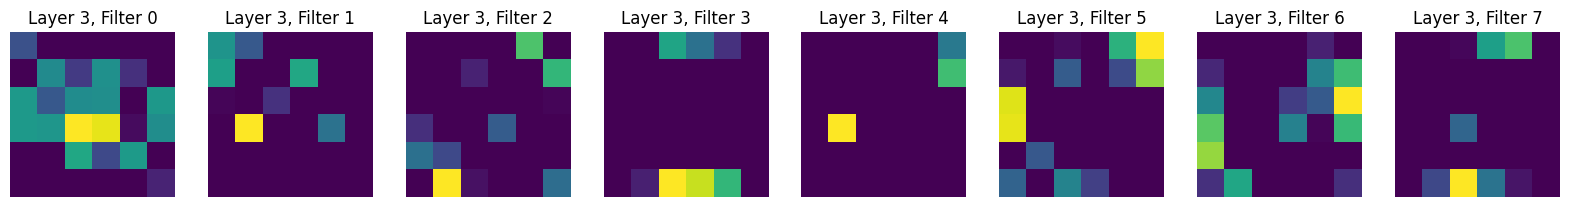

Layer 4: Output shape = (1, 2304)
Non-visualizable layer: Activation [0.7506398 1.7412755 0.        0.        0.        0.        0.
 0.        0.        0.5390969]...
Layer 5: Output shape = (1, 64)
Non-visualizable layer: Activation [ 0.        0.        0.        0.        0.        0.        0.
  0.        0.       17.933128]...
Layer 6: Output shape = (1, 64)
Non-visualizable layer: Activation [ 0.        0.        0.        0.        0.        0.        0.
  0.        0.       17.933128]...
Layer 7: Output shape = (1, 43)
Non-visualizable layer: Activation [9.9999762e-01 2.2618033e-06 1.1074395e-18 2.5194630e-25 2.0688574e-27
 3.6259640e-18 9.3605238e-15 1.9292967e-15 9.7350655e-17 9.7382398e-21]...


In [57]:
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# Define the model
model = model_simple  # Assuming your model is already built and initialized

# Extract outputs of all layers
layer_outputs = [layer.output for layer in model.layers]  # All layers' outputs

# Create a new model that returns these outputs
activation_model = Model(inputs=model.input, outputs=layer_outputs)

# Provide a test input
test_image = np.expand_dims(X_val[0], axis=0)  # Add batch dimension

# Get activations
activations = activation_model.predict(test_image)

# Visualize activations
for i, activation in enumerate(activations):
    print(f"Layer {i}: Output shape = {activation.shape}")
    if len(activation.shape) == 4:  # For 4D activations
        num_filters = activation.shape[-1]  # Number of filters in this layer
        fig, axes = plt.subplots(1, min(num_filters, 8), figsize=(20, 5))  # Show up to 8 filters
        for j in range(min(num_filters, 8)):
            axes[j].imshow(activation[0, :, :, j], cmap='viridis')  # Visualize filter
            axes[j].axis('off')
            axes[j].set_title(f"Layer {i}, Filter {j}")
        plt.show()
    else:  # For non-4D activations
        print(f"Non-visualizable layer: Activation {activation.flatten()[:10]}...")  # Print part of activation



## Que voit chaque filtre dans le modèle avancé ?

In [58]:
# Print all layer names in the model
for i, layer in enumerate(model_advanced.layers):
    print(f"Layer {i}: {layer.name}")



Layer 0: conv2d_20
Layer 1: max_pooling2d_20
Layer 2: conv2d_21
Layer 3: max_pooling2d_21
Layer 4: conv2d_22
Layer 5: max_pooling2d_22
Layer 6: flatten_8
Layer 7: dense_18
Layer 8: dropout_21
Layer 9: dense_19


1/1 [==============================] - 0s 140ms/step
Layer 0: Output shape = (1, 30, 30, 32)


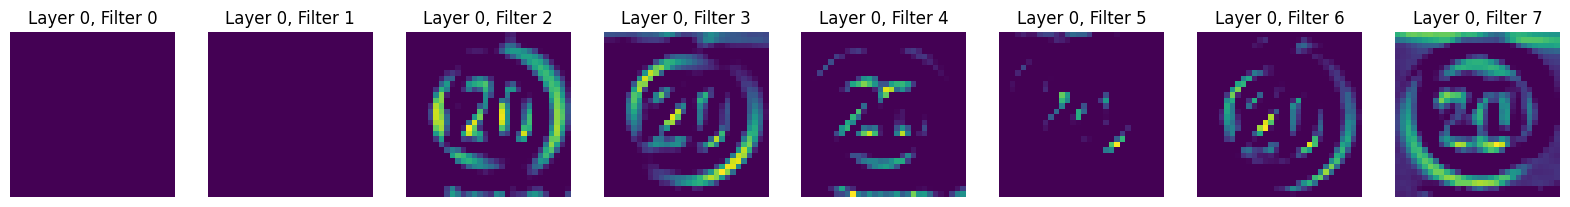

Layer 1: Output shape = (1, 15, 15, 32)


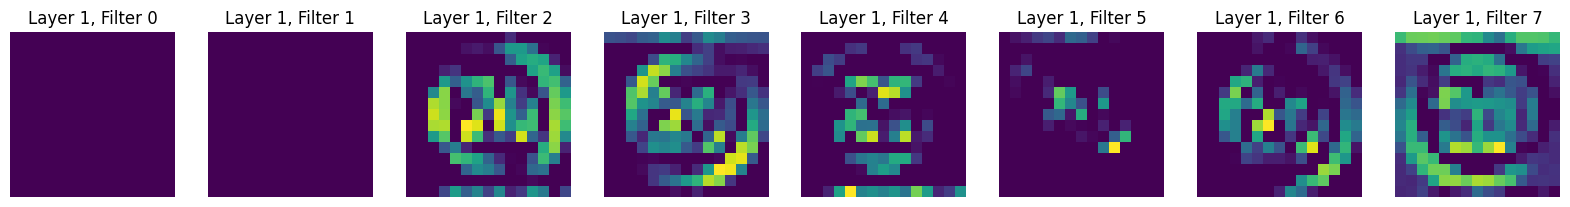

Layer 2: Output shape = (1, 13, 13, 64)


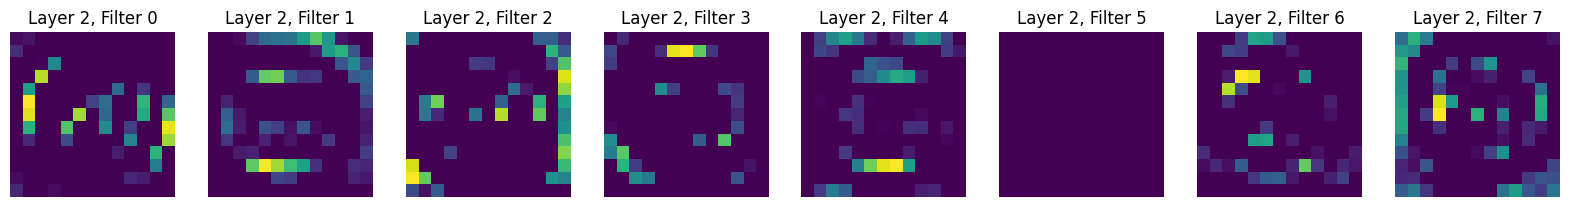

Layer 3: Output shape = (1, 6, 6, 64)


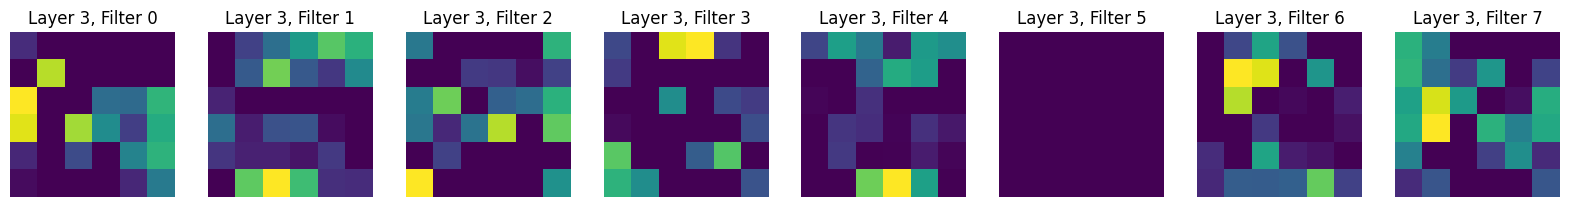

Layer 4: Output shape = (1, 4, 4, 128)


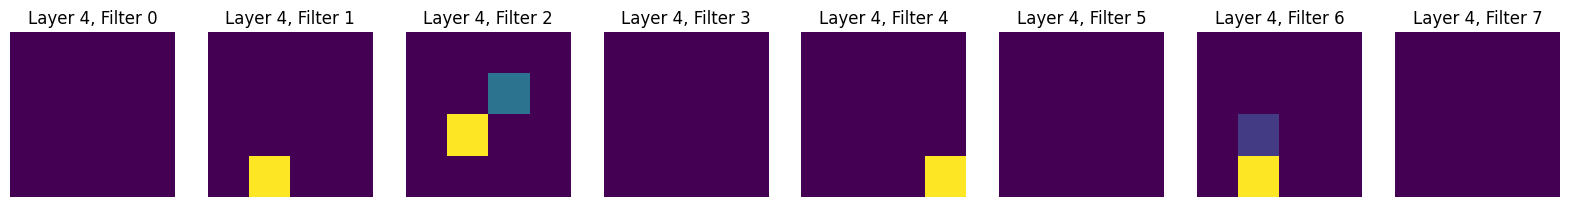

Layer 5: Output shape = (1, 2, 2, 128)


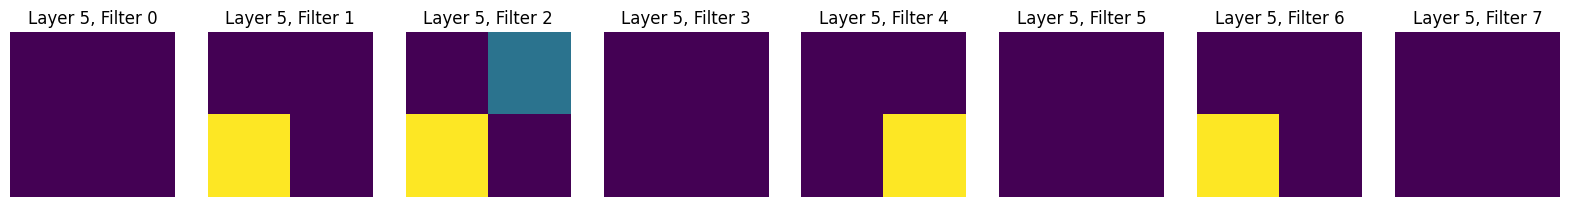

Layer 6: Output shape = (1, 512)
Non-visualizable layer: Activation [0.        0.        0.        0.        0.        0.        0.
 0.        0.        3.7817214]...
Layer 7: Output shape = (1, 128)
Non-visualizable layer: Activation [ 0.          0.         11.668286    0.          0.44925237  0.
  0.          8.797857    0.          0.6900334 ]...
Layer 8: Output shape = (1, 128)
Non-visualizable layer: Activation [ 0.          0.         11.668286    0.          0.44925237  0.
  0.          8.797857    0.          0.6900334 ]...
Layer 9: Output shape = (1, 43)
Non-visualizable layer: Activation [1.0000000e+00 1.3020098e-10 1.6381290e-27 6.2746126e-26 1.2040016e-36
 7.2339220e-25 8.2456540e-18 1.5438167e-22 2.1328264e-19 2.6090095e-27]...


In [59]:
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# Define the model
model = model_advanced  # Assuming your model is already built and initialized

# Extract outputs of all layers
layer_outputs = [layer.output for layer in model.layers]  # All layers' outputs

# Create a new model that returns these outputs
activation_model = Model(inputs=model.input, outputs=layer_outputs)

# Provide a test input
test_image = np.expand_dims(X_val[0], axis=0)  # Add batch dimension

# Get activations
activations = activation_model.predict(test_image)

# Visualize activations
for i, activation in enumerate(activations):
    print(f"Layer {i}: Output shape = {activation.shape}")
    if len(activation.shape) == 4:  # For 4D activations
        num_filters = activation.shape[-1]  # Number of filters in this layer
        fig, axes = plt.subplots(1, min(num_filters, 8), figsize=(20, 5))  # Show up to 8 filters
        for j in range(min(num_filters, 8)):
            axes[j].imshow(activation[0, :, :, j], cmap='viridis')  # Visualize filter
            axes[j].axis('off')
            axes[j].set_title(f"Layer {i}, Filter {j}")
        plt.show()
    else:  # For non-4D activations
        print(f"Non-visualizable layer: Activation {activation.flatten()[:10]}...")  # Print part of activation


## Grad-CAM

Le résultat de l'analyse Grad-CAM montre à l'oeil humain les éléments où le modèle se concentre le plus pour "prendre sa décision". Le gradient de couleur va de rouge au bleu foncé, suivant le pixel avec le poids décisionnel le plus important au moindre.

### Grad-CAM d'un panneau 70 km/h, modèle simple

1/1 [==============================] - 0s 18ms/step


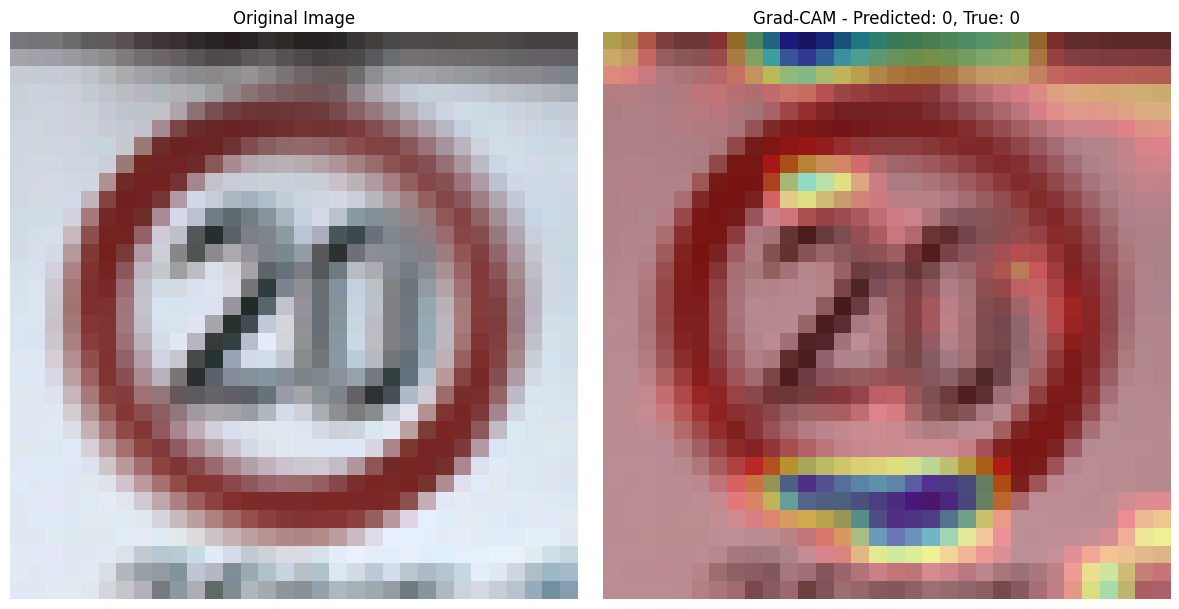

In [63]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

def get_gradcam_heatmap(model, image, class_index):
    # 🔹 Vérifier le bon nom de la dernière couche convolutive
    grad_model = Model(inputs=model.input, outputs=[model.get_layer("conv2d_16").output, model.output])  

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1).numpy()[0]

    heatmap = np.maximum(heatmap, 0)  # Remove negative values
    heatmap /= np.max(heatmap)  # Normalize between 0 and 1

    return heatmap

# 🔹 Tester sur une image
image_index = 0  # Choisir une image
test_image = X_val[image_index:image_index+1]  # Ajouter une dimension batch

# 🔹 Prédiction
predicted_class = np.argmax(model_simple.predict(test_image))
true_class = np.argmax(y_val[image_index])

# 🔹 Générer la heatmap Grad-CAM
heatmap = get_gradcam_heatmap(model_simple, test_image, predicted_class)

# 🔹 Redimensionner et normaliser la heatmap
heatmap = cv2.resize(heatmap, (test_image.shape[2], test_image.shape[1]))
heatmap = np.uint8(255 * heatmap)  
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# 🔹 Normaliser l'image de test et convertir en uint8
test_image_normalized = test_image[0] / np.max(test_image[0])  
test_image_uint8 = np.uint8(test_image_normalized * 255)

# 🔹 Superposer la heatmap
superimposed_img = cv2.addWeighted(test_image_uint8, 0.6, heatmap, 0.4, 0)

# 🔹 Affichage
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(test_image_uint8)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM - Predicted: {predicted_class}, True: {true_class}")
plt.axis("off")

plt.tight_layout()
plt.show()


### Grad-CAM des erreurs du modèle simple

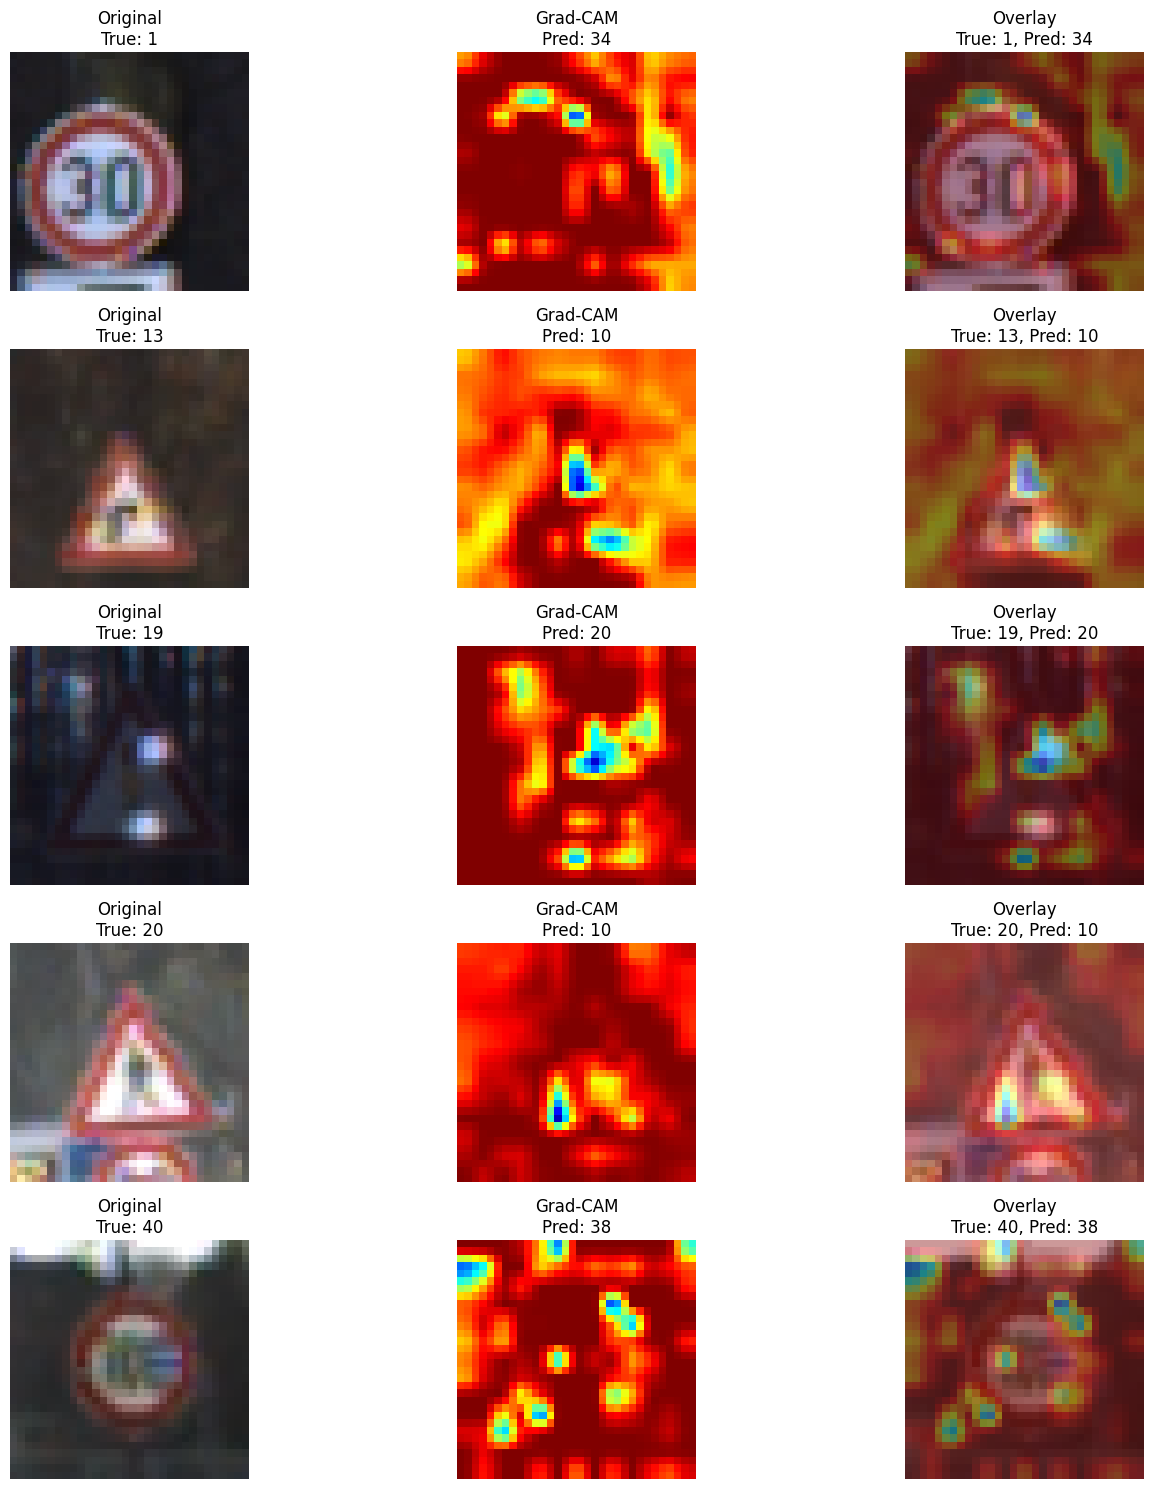

In [64]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# 🔹 Fonction Grad-CAM (avec la bonne couche convolutive)
def get_gradcam_heatmap(model, image, class_index):
    # Modifier ici avec le bon nom de la couche
    grad_model = Model(inputs=model.input, outputs=[model.get_layer("conv2d_16").output, model.output])  

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1).numpy()[0]

    heatmap = np.maximum(heatmap, 0)  # Supprimer les valeurs négatives
    heatmap /= np.max(heatmap)  # Normaliser entre 0 et 1

    return heatmap

# 🔹 Affichage des images mal classifiées avec Grad-CAM
def display_misclassified_gradcam(y_true, y_pred, X, model, num_images=5):
    misclassified_idx = np.where(y_true != y_pred)[0]
    num_images = min(num_images, len(misclassified_idx))

    plt.figure(figsize=(15, 15))

    for i in range(num_images):
        idx = misclassified_idx[i]
        img = np.expand_dims(X[idx], axis=0)  # Ajouter une dimension batch
        true_label = y_true[idx]
        predicted_label = y_pred[idx]

        # 🔹 Générer la heatmap Grad-CAM
        heatmap = get_gradcam_heatmap(model, img, predicted_label)

        # 🔹 Redimensionner et convertir la heatmap
        heatmap = cv2.resize(heatmap, (img.shape[2], img.shape[1]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # 🔹 Normaliser l'image pour l'affichage
        img_normalized = X[idx] / np.max(X[idx])  
        img_uint8 = np.uint8(img_normalized * 255)

        # 🔹 Superposer la heatmap sur l'image originale
        overlay = cv2.addWeighted(img_uint8, 0.6, heatmap, 0.4, 0)

        # 🔹 Affichage des images
        plt.subplot(num_images, 3, i * 3 + 1)
        plt.imshow(img_uint8)
        plt.title(f"Original\nTrue: {true_label}")
        plt.axis('off')

        plt.subplot(num_images, 3, i * 3 + 2)
        plt.imshow(heatmap)
        plt.title(f"Grad-CAM\nPred: {predicted_label}")
        plt.axis('off')

        plt.subplot(num_images, 3, i * 3 + 3)
        plt.imshow(overlay)
        plt.title(f"Overlay\nTrue: {true_label}, Pred: {predicted_label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 🔹 Affichage des erreurs avec Grad-CAM
display_misclassified_gradcam(
    np.array(last_y_true_simple),
    np.array(last_y_pred_simple),
    np.array(last_X_simple),
    model=model_simple,  
    num_images=5
)


### Grad-CAM d'un panneau 70 km/h, modèle avancé

Pour ce panneau limitant la vitesse à 70 km/h ci-dessous, la couche 2d a basé sa classification sur le côté supérieur gauche de l'image et un peu sur le bord.

conv2d_20
max_pooling2d_20
conv2d_21
max_pooling2d_21
conv2d_22
max_pooling2d_22
flatten_8
dense_18
dropout_21
dense_19
1/1 [==============================] - 0s 18ms/step


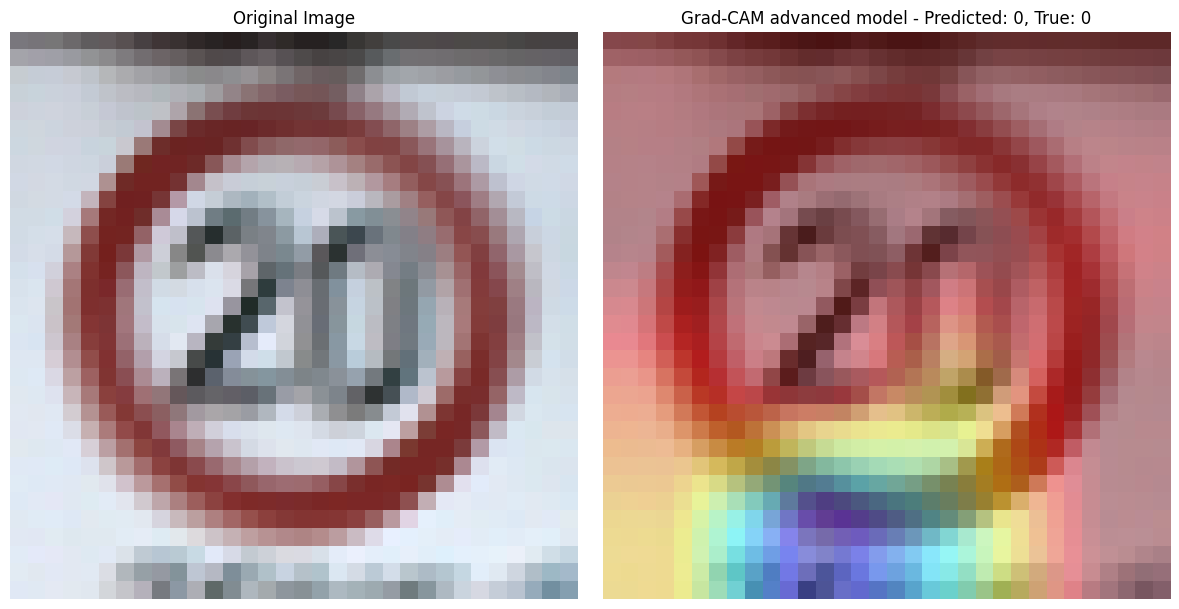

In [67]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# 🔹 Vérification des couches du modèle
for layer in model_advanced.layers:
    print(layer.name)

# 🔹 Fonction Grad-CAM avec la bonne couche Conv2D
def get_gradcam_heatmap(model, image, class_index):
    # Mettre la bonne couche ici
    grad_model = Model(inputs=model.input, outputs=[model.get_layer("conv2d_22").output, model.output])  

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1).numpy()[0]

    heatmap = np.maximum(heatmap, 0)  # Supprimer les valeurs négatives
    heatmap /= np.max(heatmap)  # Normaliser entre 0 et 1

    return heatmap

# 🔹 Image de test
image_index = 0  # Choisir une image
test_image = X_val[image_index:image_index+1]  # Ajouter une dimension batch

# 🔹 Prédiction du modèle
predicted_class = np.argmax(model_advanced.predict(test_image))
true_class = np.argmax(y_val[image_index])

# 🔹 Génération de la heatmap Grad-CAM
heatmap = get_gradcam_heatmap(model_advanced, test_image, predicted_class)

# 🔹 Redimensionner et convertir la heatmap
heatmap = cv2.resize(heatmap, (test_image.shape[2], test_image.shape[1]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# 🔹 Normaliser l'image de test
test_image_normalized = test_image[0] / np.max(test_image[0])  
test_image_uint8 = np.uint8(test_image_normalized * 255)

# 🔹 Superposition de la heatmap sur l'image originale
superimposed_img = cv2.addWeighted(test_image_uint8, 0.6, heatmap, 0.4, 0)

# 🔹 Affichage des résultats
plt.figure(figsize=(12, 6))

# 🔹 Image originale
plt.subplot(1, 2, 1)
plt.imshow(test_image_uint8)
plt.title("Original Image")
plt.axis("off")

# 🔹 Grad-CAM Overlay
plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM advanced model - Predicted: {predicted_class}, True: {true_class}")
plt.axis("off")

plt.tight_layout()
plt.show()


### Grad-CAM des erreurs du modèle avancé

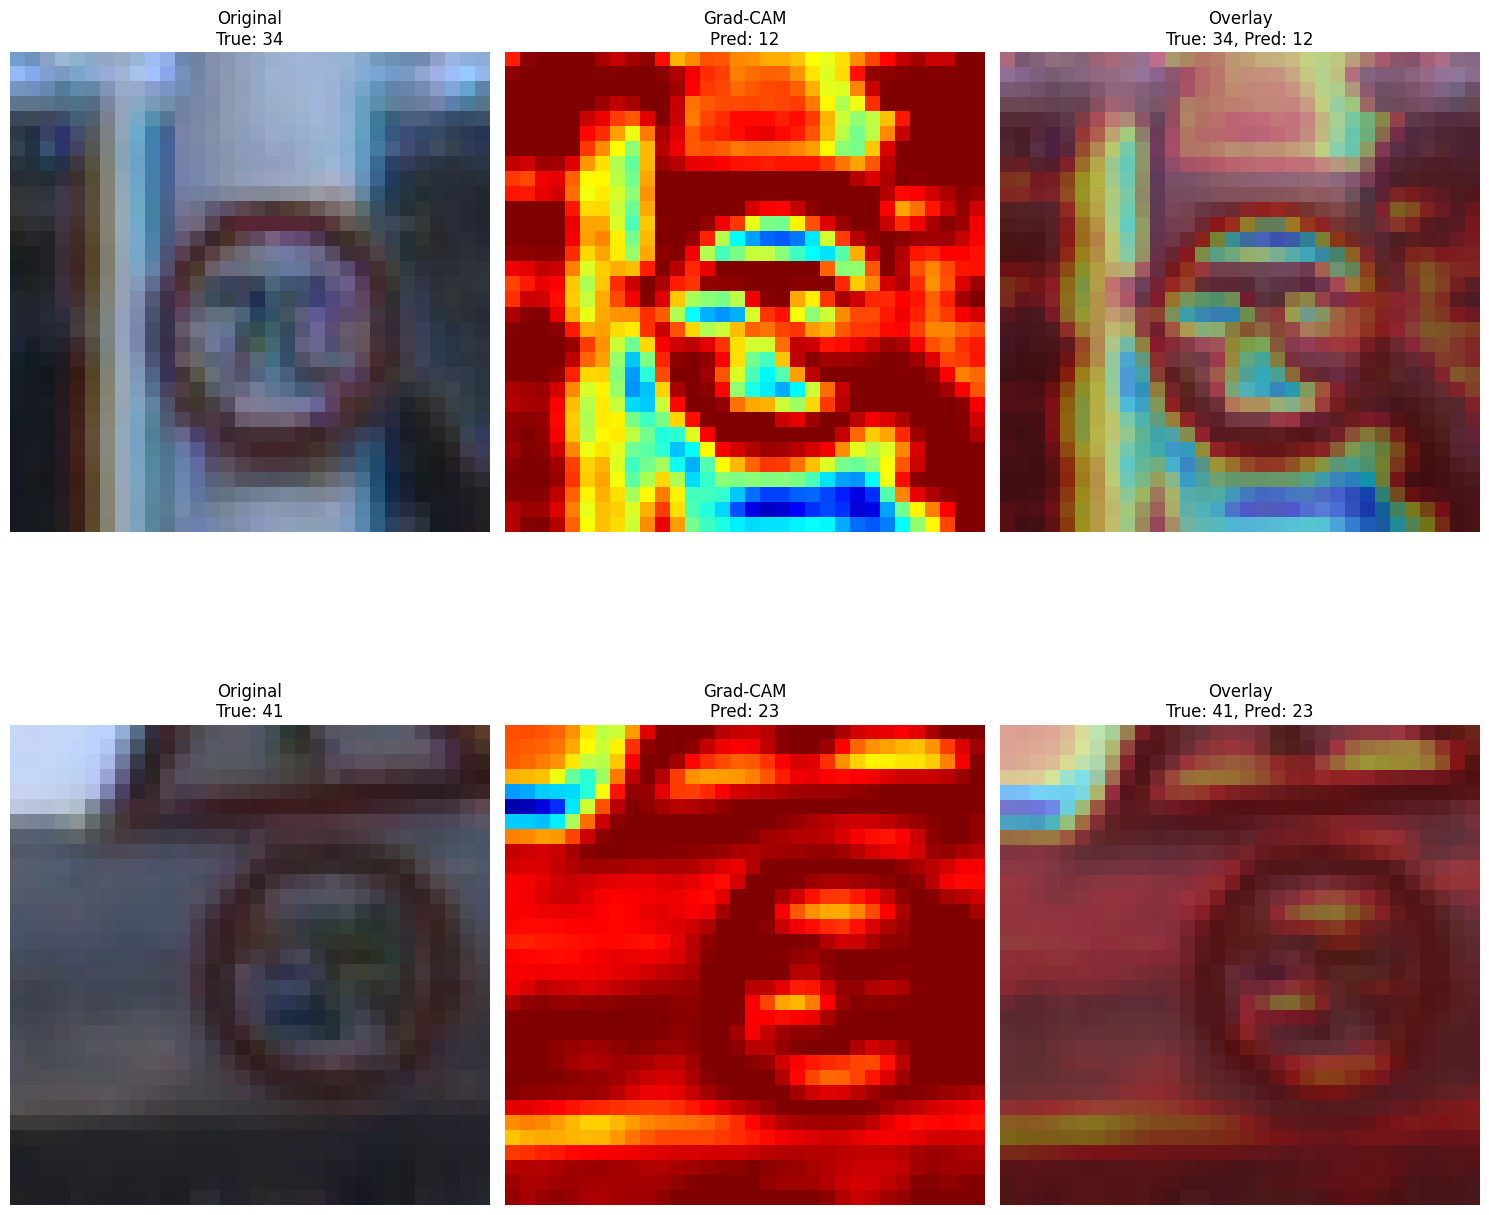

In [68]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# Grad-CAM function (reuse from before)
def get_gradcam_heatmap(model, image, class_index):
    # Specify the layer to use for Grad-CAM (update as needed)
    grad_model = Model(inputs=model.input, outputs=[model.get_layer("conv2d_20").output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1).numpy()[0]

    heatmap = np.maximum(heatmap, 0)  # Remove negative values
    heatmap /= np.max(heatmap)  # Normalize between 0 and 1

    return heatmap

# Display misclassified images with Grad-CAM
def display_misclassified_gradcam(y_true, y_pred, X, model, num_images=5):
    # Identify misclassified indices
    misclassified_idx = np.where(y_true != y_pred)[0]

    # Limit to the specified number of images
    num_images = min(num_images, len(misclassified_idx))

    plt.figure(figsize=(15, 15))

    for i in range(num_images):
        idx = misclassified_idx[i]
        img = np.expand_dims(X[idx], axis=0)  # Add batch dimension
        true_label = y_true[idx]
        predicted_label = y_pred[idx]

        # Generate Grad-CAM heatmap
        heatmap = get_gradcam_heatmap(model, img, predicted_label)

        # Resize and convert heatmap for overlay
        heatmap = cv2.resize(heatmap, (img.shape[2], img.shape[1]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # Normalize image for visualization
        img_normalized = X[idx] / np.max(X[idx])  # Normalize if needed
        img_uint8 = np.uint8(img_normalized * 255)

        # Overlay heatmap on the original image
        overlay = cv2.addWeighted(img_uint8, 0.6, heatmap, 0.4, 0)

        # Display original, Grad-CAM heatmap, and overlay
        plt.subplot(num_images, 3, i * 3 + 1)
        plt.imshow(img_uint8)
        plt.title(f"Original\nTrue: {true_label}")
        plt.axis('off')

        plt.subplot(num_images, 3, i * 3 + 2)
        plt.imshow(heatmap)
        plt.title(f"Grad-CAM\nPred: {predicted_label}")
        plt.axis('off')

        plt.subplot(num_images, 3, i * 3 + 3)
        plt.imshow(overlay)
        plt.title(f"Overlay\nTrue: {true_label}, Pred: {predicted_label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Use the stored predictions and true labels from the last fold
display_misclassified_gradcam(
    np.array(last_y_true_advanced),
    np.array(last_y_pred_advanced),
    np.array(last_X_advanced),
    model=model_advanced,  # Use the advanced model here
    num_images=5
)


## Matrice de confusion du modèle avancé


[ 0  0  0 ... 42 42 42]
246/246 [==============================] - 0s 2ms/step


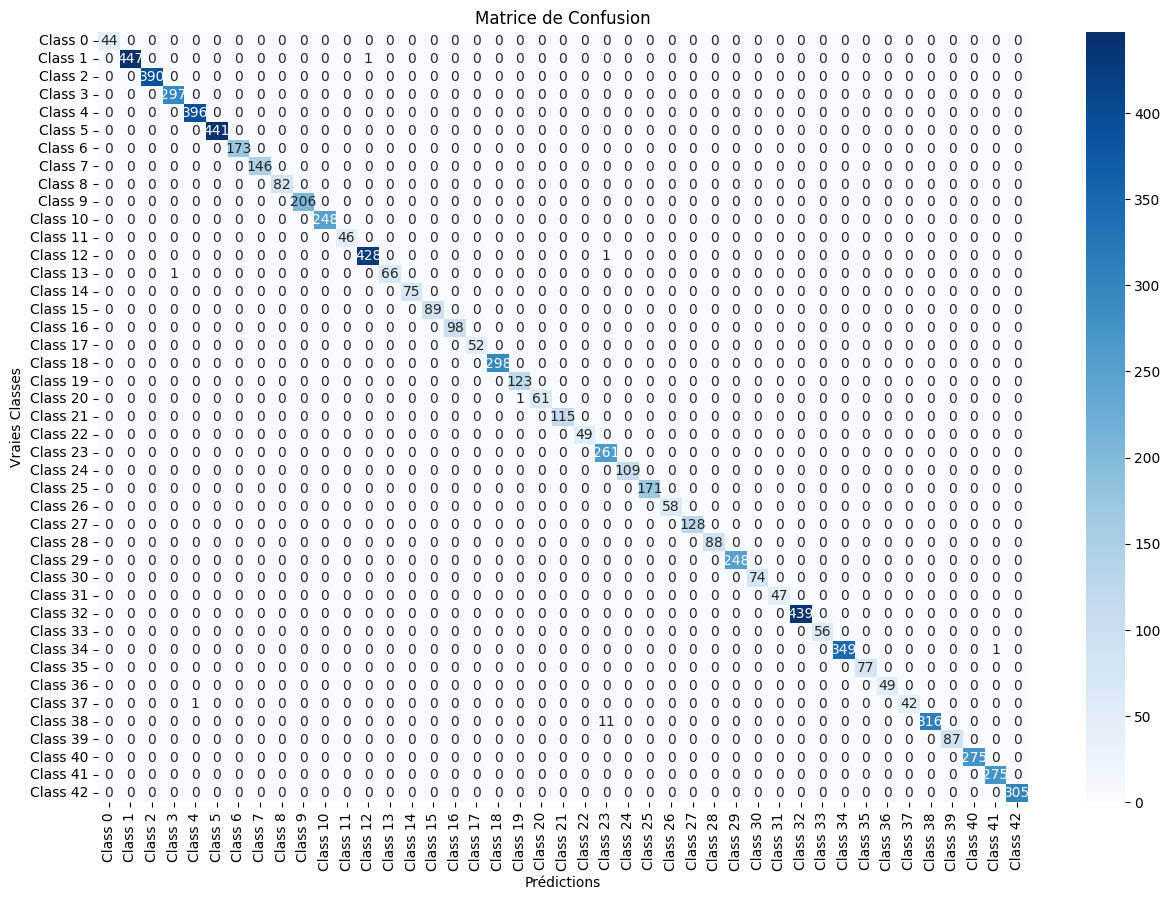

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class_indices = np.argmax(y, axis=1)
print(class_indices)
# Ensure class indices are properly defined
class_names = [f'Class {i}' for i in np.unique(class_indices)]  # Create labels from class indices

# Generate predictions
y_pred = np.argmax(model_advanced.predict(X_val), axis=1)
y_true = np.argmax(y_val, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prédictions")
plt.ylabel("Vraies Classes")
plt.title("Matrice de Confusion")
plt.show()



1/1 [==============================] - 0s 55ms/step


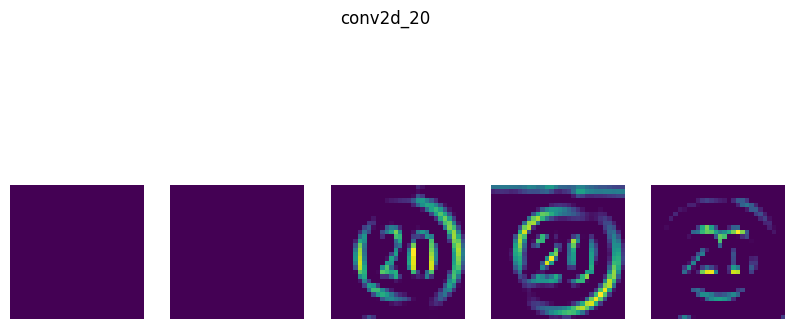

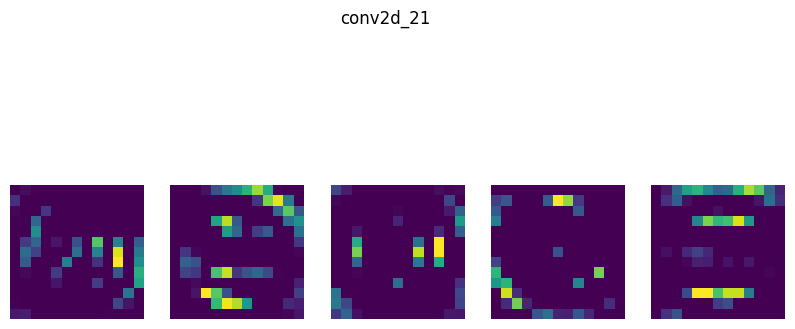

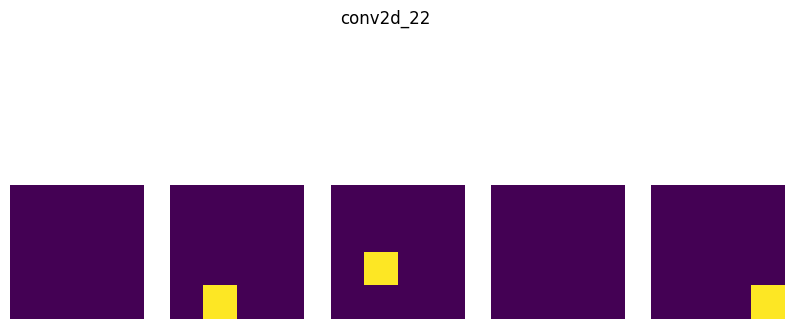

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# Choose an image from your dataset
img = X[0]  # Assuming X contains your images
img = np.expand_dims(img, axis=0)  # Add batch dimension

# Define a model that outputs the activations of intermediate layers
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]  # Get conv layers
activation_model = Model(inputs=model.input, outputs=layer_outputs)

# Get activations
activations = activation_model.predict(img)

# Plot activations
layer_names = [layer.name for layer in model.layers if 'conv' in layer.name]
for layer_name, activation in zip(layer_names, activations):
    num_filters = activation.shape[-1]
    fig, axes = plt.subplots(1, min(num_filters, 5), figsize=(10, 5))  # Show only 5 filters
    fig.suptitle(layer_name)
    for i in range(min(num_filters, 5)):
        axes[i].imshow(activation[0, :, :, i], cmap='viridis')
        axes[i].axis('off')
    plt.show()
